# Quantitative Portfolio Construction

### By: **Drew Glover**

## 1. Data Preparation

### 1.1 Data Extraction

In [1]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
import warnings
import requests
warnings.filterwarnings('ignore')

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

sp500 = pd.read_html(response.text)[0]
sp500.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [2]:
# Data cleaning for merging with yfinance data
sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-')

symbols_list = sp500['Symbol'].unique().tolist()
symbols_list[:5]

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']

In [3]:
# Defining date that we want the data for
end_date = '2025-12-31'
start_date = pd.to_datetime(end_date) - pd.DateOffset(365*8)
start_date

Timestamp('2018-01-02 00:00:00')

In [4]:
from curl_cffi import requests
session = requests.Session(impersonate="chrome")

# Download the stock data from yfinance
df = yf.download(tickers=symbols_list,
                start=start_date,
                end=end_date, session=session, auto_adjust=False)

[*********************100%***********************]  503 of 503 completed


In [5]:
df.tail()

Price        Adj Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2025-12-23  137.798737  272.105377  226.963898  136.490005  123.912323   
2025-12-24  137.758896  273.554016  228.055130  136.779999  124.180954   
2025-12-26  137.828598  273.144409  228.144394  136.820007  124.210808   
2025-12-29  137.370468  273.504089  228.997543  136.619995  123.942169   
2025-12-30  137.061722  272.824707  227.906326  136.910004  125.146072   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2025-12-23  96.959999  270.769989  352.420013  275.866241  57.040073  ...   
2025-12-24  96.400002  269.980011  352.980011  276.693634  57.347752  ...   
2025-12-26  95.870003  271.089996  353.799988  275.975861  57.476780  ...   
2025-12-29  96.389999  271.339996  353.160004  274.769653  57.784462  ...   
2025-12-30  96.660004  270.000000  352.510010  273.962189  57.734833  ...   

Price        Volume                                                        \
Ticker           WY     WYNN      XEL       XOM     XYL      XYZ      YUM   
Date                                                                        
2025-12-23  5226800  1096700  8072400  12567600  683200  5068200  1660200   
2025-12-24  1935800   615000  1427600   6137400  303700  3017700   878600   
2025-12-26  3510600   717300  2354300   8066100  484600  3118400  1086400   
2025-12-29  3841600  1017200  3999500  14782500  646500  4216700  1963000   
2025-12-30  3495800   689900  5420800  11150500  531900  2958800  1158600   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2025-12-23  1337500  526000  4952000  
2025-12-24   623200  374200  2369000  
2025-12-26   967500  622400  3226800  
2025-12-29   924500  563900  4465600  
2025-12-30   934500  492400  3230200  

[5 rows x 3018 columns]

Creating a copy of df in case we need it again

In [6]:
df_copy = df.copy()
df_copy.tail()

Price        Adj Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2025-12-23  137.798737  272.105377  226.963898  136.490005  123.912323   
2025-12-24  137.758896  273.554016  228.055130  136.779999  124.180954   
2025-12-26  137.828598  273.144409  228.144394  136.820007  124.210808   
2025-12-29  137.370468  273.504089  228.997543  136.619995  123.942169   
2025-12-30  137.061722  272.824707  227.906326  136.910004  125.146072   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2025-12-23  96.959999  270.769989  352.420013  275.866241  57.040073  ...   
2025-12-24  96.400002  269.980011  352.980011  276.693634  57.347752  ...   
2025-12-26  95.870003  271.089996  353.799988  275.975861  57.476780  ...   
2025-12-29  96.389999  271.339996  353.160004  274.769653  57.784462  ...   
2025-12-30  96.660004  270.000000  352.510010  273.962189  57.734833  ...   

Price        Volume                                                        \
Ticker           WY     WYNN      XEL       XOM     XYL      XYZ      YUM   
Date                                                                        
2025-12-23  5226800  1096700  8072400  12567600  683200  5068200  1660200   
2025-12-24  1935800   615000  1427600   6137400  303700  3017700   878600   
2025-12-26  3510600   717300  2354300   8066100  484600  3118400  1086400   
2025-12-29  3841600  1017200  3999500  14782500  646500  4216700  1963000   
2025-12-30  3495800   689900  5420800  11150500  531900  2958800  1158600   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2025-12-23  1337500  526000  4952000  
2025-12-24   623200  374200  2369000  
2025-12-26   967500  622400  3226800  
2025-12-29   924500  563900  4465600  
2025-12-30   934500  492400  3230200  

[5 rows x 3018 columns]

In [7]:
df = df_copy.copy()
df.tail()

Price        Adj Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2025-12-23  137.798737  272.105377  226.963898  136.490005  123.912323   
2025-12-24  137.758896  273.554016  228.055130  136.779999  124.180954   
2025-12-26  137.828598  273.144409  228.144394  136.820007  124.210808   
2025-12-29  137.370468  273.504089  228.997543  136.619995  123.942169   
2025-12-30  137.061722  272.824707  227.906326  136.910004  125.146072   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2025-12-23  96.959999  270.769989  352.420013  275.866241  57.040073  ...   
2025-12-24  96.400002  269.980011  352.980011  276.693634  57.347752  ...   
2025-12-26  95.870003  271.089996  353.799988  275.975861  57.476780  ...   
2025-12-29  96.389999  271.339996  353.160004  274.769653  57.784462  ...   
2025-12-30  96.660004  270.000000  352.510010  273.962189  57.734833  ...   

Price        Volume                                                        \
Ticker           WY     WYNN      XEL       XOM     XYL      XYZ      YUM   
Date                                                                        
2025-12-23  5226800  1096700  8072400  12567600  683200  5068200  1660200   
2025-12-24  1935800   615000  1427600   6137400  303700  3017700   878600   
2025-12-26  3510600   717300  2354300   8066100  484600  3118400  1086400   
2025-12-29  3841600  1017200  3999500  14782500  646500  4216700  1963000   
2025-12-30  3495800   689900  5420800  11150500  531900  2958800  1158600   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2025-12-23  1337500  526000  4952000  
2025-12-24   623200  374200  2369000  
2025-12-26   967500  622400  3226800  
2025-12-29   924500  563900  4465600  
2025-12-30   934500  492400  3230200  

[5 rows x 3018 columns]

### 1.2 Data Cleaning

We need to change the df format to a stack, so that we have more rows, and less columns, where the columns are simply the metrics, and the rows are a unique combination of date and ticker symbol.

In [8]:
df = df.stack()
df.tail()

Price               Adj Close       Close        High         Low        Open  \
Date       Ticker                                                               
2025-12-30 XYZ      65.540001   65.540001   65.989998   65.449997   65.830002   
           YUM     151.481842  152.179993  152.660004  151.449997  151.679993   
           ZBH      90.544121   90.790001   90.919998   89.879997   90.180000   
           ZBRA    246.740005  246.740005  247.039993  243.320007  244.619995   
           ZTS     125.872520  126.410004  127.599998  125.449997  125.550003   

Price                 Volume  
Date       Ticker             
2025-12-30 XYZ     2958800.0  
           YUM     1158600.0  
           ZBH      934500.0  
           ZBRA     492400.0  
           ZTS     3230200.0

In [9]:
df.index.names = ['date', 'ticker']
df.tail()

Price               Adj Close       Close        High         Low        Open  \
date       ticker                                                               
2025-12-30 XYZ      65.540001   65.540001   65.989998   65.449997   65.830002   
           YUM     151.481842  152.179993  152.660004  151.449997  151.679993   
           ZBH      90.544121   90.790001   90.919998   89.879997   90.180000   
           ZBRA    246.740005  246.740005  247.039993  243.320007  244.619995   
           ZTS     125.872520  126.410004  127.599998  125.449997  125.550003   

Price                 Volume  
date       ticker             
2025-12-30 XYZ     2958800.0  
           YUM     1158600.0  
           ZBH      934500.0  
           ZBRA     492400.0  
           ZTS     3230200.0

Changing the column names to lower case

In [10]:
df.columns = df.columns.str.lower()
df.tail()

Price               adj close       close        high         low        open  \
date       ticker                                                               
2025-12-30 XYZ      65.540001   65.540001   65.989998   65.449997   65.830002   
           YUM     151.481842  152.179993  152.660004  151.449997  151.679993   
           ZBH      90.544121   90.790001   90.919998   89.879997   90.180000   
           ZBRA    246.740005  246.740005  247.039993  243.320007  244.619995   
           ZTS     125.872520  126.410004  127.599998  125.449997  125.550003   

Price                 volume  
date       ticker             
2025-12-30 XYZ     2958800.0  
           YUM     1158600.0  
           ZBH      934500.0  
           ZBRA     492400.0  
           ZTS     3230200.0

## 2. Exploration of Technical Indicators and Features of Stocks

Feature Engineering for the following features/indicators:
1. Garman-Klass Volatility
2. RSI
3. Bollinger Bands
4. ATR
5. MACD

### 2.1 Garman-Klass Volatility

Garman-Klass volatility uses **open, high, low, and closing prices** to provide a more accurate estimate of a stock's volatility than typical methods that only consider closing prices. It captures **intraday price movements** and is often used to **assess the risk associated with a stock**, especially in relation to its potential for rapid price changes.

It is calculated as follows:
$$
\text{Garman--Klass Volatility}
= \frac{\bigl(\ln(\mathrm{High}) - \ln(\mathrm{Low})\bigr)^2}{2}
\;-\;\bigl(2\ln(2)-1\bigr)\,\bigl(\ln(\mathrm{Adj\ Close}) - \ln(\mathrm{Open})\bigr)^2
$$


In [11]:
df['garman_klass_vol'] = ((np.log(df['high']) - np.log(df['low']))**2)/2 - (2*np.log(2) - 1)*((np.log(df['adj close']) - np.log(df['open']))**2)

df.head()

Price              adj close      close       high        low       open  \
date       ticker                                                          
2018-01-02 A       63.522766  67.599998  67.889999  67.339996  67.419998   
           AAPL    40.304176  43.064999  43.075001  42.314999  42.540001   
           ABBV    69.343712  98.410004  98.900002  96.750000  97.139999   
           ABT     50.822922  58.790001  59.200001  57.820000  58.200001   
           ACGL    27.988113  29.433332  30.420000  29.383333  30.403334   

Price                   volume  garman_klass_vol  
date       ticker                                 
2018-01-02 A         1047800.0         -0.001336  
           AAPL    102223600.0         -0.000968  
           ABBV      4561300.0         -0.043650  
           ABT      10112800.0         -0.006818  
           ACGL      1333500.0         -0.002046

### 2.2 RSI

The Relative Strength Index (RSI) is a technical indicator that measures the **speed and magnitude of price changes on a stock**, providing insights into its momentum. It's often used to identify **potential overbought or oversold conditions**.

In [12]:
RSI_LEN = 60
df['rsi'] = df.groupby(level=1)['adj close'] \
              .transform(lambda x: pandas_ta.rsi(close=x, length=RSI_LEN))

In [13]:
df.tail()

Price               adj close       close        high         low        open  \
date       ticker                                                               
2025-12-30 XYZ      65.540001   65.540001   65.989998   65.449997   65.830002   
           YUM     151.481842  152.179993  152.660004  151.449997  151.679993   
           ZBH      90.544121   90.790001   90.919998   89.879997   90.180000   
           ZBRA    246.740005  246.740005  247.039993  243.320007  244.619995   
           ZTS     125.872520  126.410004  127.599998  125.449997  125.550003   

Price                 volume  garman_klass_vol        rsi  
date       ticker                                          
2025-12-30 XYZ     2958800.0          0.000026  47.825396  
           YUM     1158600.0          0.000031  52.709799  
           ZBH      934500.0          0.000060  46.484401  
           ZBRA     492400.0          0.000086  43.936605  
           ZTS     3230200.0          0.000142  44.378500

Plotting RSI of AAPL to check

<Axes: xlabel='date'>

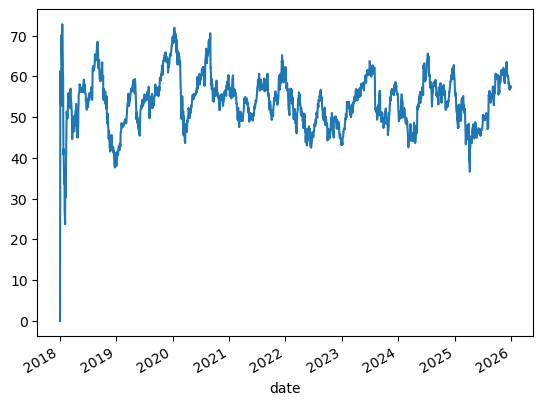

In [14]:
df.xs('AAPL', level=1)['rsi'].plot()

### 2.3 Bollinger Bands

Bollinger Bands are a technical analysis tool that helps traders assess a stock's price **volatility** and identify potential trading opportunities. They consist of a **middle band (a moving average) and two outer bands (standard deviations away from the moving average)**. By observing how the price moves in relation to these bands, traders can gauge whether a stock is **overbought, oversold, or experiencing a potential trend change**.

We will be calculating the 3 different Bollinger Bands (low, mid, high) below:

In [15]:
df['bb_low'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,0])
df['bb_mid'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,1])
df['bb_high'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,2])

df.tail()

Price               adj close       close        high         low        open  \
date       ticker                                                               
2025-12-30 XYZ      65.540001   65.540001   65.989998   65.449997   65.830002   
           YUM     151.481842  152.179993  152.660004  151.449997  151.679993   
           ZBH      90.544121   90.790001   90.919998   89.879997   90.180000   
           ZBRA    246.740005  246.740005  247.039993  243.320007  244.619995   
           ZTS     125.872520  126.410004  127.599998  125.449997  125.550003   

Price                 volume  garman_klass_vol        rsi    bb_low    bb_mid  \
date       ticker                                                               
2025-12-30 XYZ     2958800.0          0.000026  47.825396  4.110362  4.169891   
           YUM     1158600.0          0.000031  52.709799  4.956793  5.013605   
           ZBH      934500.0          0.000060  46.484401  4.490710  4.523421   
           ZBRA     492400.0          0.000086  43.936605  5.482913  5.554163   
           ZTS     3230200.0          0.000142  44.378500  4.754446  4.806522   

Price               bb_high  
date       ticker            
2025-12-30 XYZ     4.229420  
           YUM     5.070417  
           ZBH     4.556132  
           ZBRA    5.625413  
           ZTS     4.858599

### 2.4 ATR

The Average True Range (ATR) is a technical analysis indicator that measures **price volatility over a specific period, typically 14 days**. It helps traders understand how much a stock's price fluctuates and can be used to **set stop-loss levels and manage risk**. 

In [16]:
pandas_ta.atr(high=df['high'],
             low=df['low'],
             close=df['close'],
             length=14)

date        ticker
2018-01-02  A                NaN
            AAPL             NaN
            ABBV             NaN
            ABT              NaN
            ACGL             NaN
                         ...    
2025-12-30  XYZ       120.368479
            YUM       117.993588
            ZBH       114.015474
            ZBRA      117.032225
            ZTS       117.336353
Name: ATRr_14, Length: 989700, dtype: float64

In [17]:
def compute_atr(stock_data):
    return pandas_ta.atr(high=stock_data['high'],
             low=stock_data['low'],
             close=stock_data['close'],
             length=14) 

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)
df.tail()

Price               adj close       close        high         low        open  \
date       ticker                                                               
2025-12-30 XYZ      65.540001   65.540001   65.989998   65.449997   65.830002   
           YUM     151.481842  152.179993  152.660004  151.449997  151.679993   
           ZBH      90.544121   90.790001   90.919998   89.879997   90.180000   
           ZBRA    246.740005  246.740005  247.039993  243.320007  244.619995   
           ZTS     125.872520  126.410004  127.599998  125.449997  125.550003   

Price                 volume  garman_klass_vol        rsi    bb_low    bb_mid  \
date       ticker                                                               
2025-12-30 XYZ     2958800.0          0.000026  47.825396  4.110362  4.169891   
           YUM     1158600.0          0.000031  52.709799  4.956793  5.013605   
           ZBH      934500.0          0.000060  46.484401  4.490710  4.523421   
           ZBRA     492400.0          0.000086  43.936605  5.482913  5.554163   
           ZTS     3230200.0          0.000142  44.378500  4.754446  4.806522   

Price               bb_high       atr  
date       ticker                      
2025-12-30 XYZ     4.229420  1.957235  
           YUM     5.070417  2.553986  
           ZBH     4.556132  1.868275  
           ZBRA    5.625413  6.738527  
           ZTS     4.858599  2.769758

### 2.5 MACD

The MACD (Moving Average Convergence Divergence) is a technical indicator that helps investors **identify trends, momentum, and potential entry and exit points** for trades in a stock. It does this by **showing the relationship between two exponential moving averages (EMAs) of a stock's price**. 

In [18]:
def compute_macd(close):
    return pandas_ta.macd(close=close, length=20).iloc[:,0]

df['macd'] = df.groupby(level=1, group_keys=False)['adj close'].apply(compute_macd)
df.tail()

Price               adj close       close        high         low        open  \
date       ticker                                                               
2025-12-30 XYZ      65.540001   65.540001   65.989998   65.449997   65.830002   
           YUM     151.481842  152.179993  152.660004  151.449997  151.679993   
           ZBH      90.544121   90.790001   90.919998   89.879997   90.180000   
           ZBRA    246.740005  246.740005  247.039993  243.320007  244.619995   
           ZTS     125.872520  126.410004  127.599998  125.449997  125.550003   

Price                 volume  garman_klass_vol        rsi    bb_low    bb_mid  \
date       ticker                                                               
2025-12-30 XYZ     2958800.0          0.000026  47.825396  4.110362  4.169891   
           YUM     1158600.0          0.000031  52.709799  4.956793  5.013605   
           ZBH      934500.0          0.000060  46.484401  4.490710  4.523421   
           ZBRA     492400.0          0.000086  43.936605  5.482913  5.554163   
           ZTS     3230200.0          0.000142  44.378500  4.754446  4.806522   

Price               bb_high       atr      macd  
date       ticker                                
2025-12-30 XYZ     4.229420  1.957235  0.052288  
           YUM     5.070417  2.553986  1.540267  
           ZBH     4.556132  1.868275 -0.961963  
           ZBRA    5.625413  6.738527 -3.863525  
           ZTS     4.858599  2.769758  0.071802

### 2.6 Dollar Volume

We are using the Dollar Volume statistic for filtering the 5y rolling average dollar volume in section 3, to filter the top 100 most liquid stocks every month. This statistic will be deleted afterwards as it is not a technical indicator feature we will be backtesting any trading signals on.

We divide by 1M to make the number smaller rather than model on huge numbers, and so dollar_volume is in millions

In [19]:
df['dollar_volume'] = (df['adj close']*df['volume'])/1e6
df.tail()

Price               adj close       close        high         low        open  \
date       ticker                                                               
2025-12-30 XYZ      65.540001   65.540001   65.989998   65.449997   65.830002   
           YUM     151.481842  152.179993  152.660004  151.449997  151.679993   
           ZBH      90.544121   90.790001   90.919998   89.879997   90.180000   
           ZBRA    246.740005  246.740005  247.039993  243.320007  244.619995   
           ZTS     125.872520  126.410004  127.599998  125.449997  125.550003   

Price                 volume  garman_klass_vol        rsi    bb_low    bb_mid  \
date       ticker                                                               
2025-12-30 XYZ     2958800.0          0.000026  47.825396  4.110362  4.169891   
           YUM     1158600.0          0.000031  52.709799  4.956793  5.013605   
           ZBH      934500.0          0.000060  46.484401  4.490710  4.523421   
           ZBRA     492400.0          0.000086  43.936605  5.482913  5.554163   
           ZTS     3230200.0          0.000142  44.378500  4.754446  4.806522   

Price               bb_high       atr      macd  dollar_volume  
date       ticker                                               
2025-12-30 XYZ     4.229420  1.957235  0.052288     193.919755  
           YUM     5.070417  2.553986  1.540267     175.506862  
           ZBH     4.556132  1.868275 -0.961963      84.613481  
           ZBRA    5.625413  6.738527 -3.863525     121.494779  
           ZTS     4.858599  2.769758  0.071802     406.593416

## 3. Aggregate to monthly level and filter top 100 most liquid stocks for each month

We will be extracting the **top 100 most liquid companies by 5y rolling average dollar_volume**, and aggregating the features to **monthly level** for just the technical indicators (not open/close/high/low type of stats).

In [20]:
# Demo-ing the process for unstacking and aggregating the dollar_volume column 
df.unstack('ticker')['dollar_volume'].resample('M').mean().stack('ticker').to_frame('dollar_volume')

dollar_volume
date       ticker               
2018-01-31 A          124.193758
           AAPL      5102.544469
           ABBV       526.992762
           ABT        389.401985
           ACGL        46.003407
...                          ...
2025-12-31 XYZ        428.026520
           YUM        325.353279
           ZBH        188.464275
           ZBRA       145.088357
           ZTS        745.328872

[47282 rows x 1 columns]

Obtain the list of columns of technical indicators we want to aggregate the data for

In [21]:
last_cols = [c for c in df.columns.unique(0) if c not in ['dollar_volume', 'volume', 'open', 'high', 'low', 'close']]
last_cols

['adj close',
 'garman_klass_vol',
 'rsi',
 'bb_low',
 'bb_mid',
 'bb_high',
 'atr',
 'macd']

In [22]:
df.unstack()[last_cols].resample('M').last().stack('ticker')

Price               adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2018-01-31 A        69.001152         -0.001604  95.999891  4.182222   
           AAPL     39.174091         -0.001461  35.030320  3.689631   
           ABBV     79.642006         -0.054107  86.495076  4.191439   
           ABT      53.993233         -0.008454  83.079300  3.911991   
           ACGL     28.824903         -0.000897  67.175947  3.346834   
...                       ...               ...        ...       ...   
2025-12-31 XYZ      65.540001          0.000026  47.825396  4.110362   
           YUM     151.481842          0.000031  52.709799  4.956793   
           ZBH      90.544121          0.000060  46.484401  4.490710   
           ZBRA    246.740005          0.000086  43.936605  5.482913   
           ZTS     125.872520          0.000142  44.378500  4.754446   

Price                bb_mid   bb_high       atr      macd  
date       ticker                                          
2018-01-31 A       4.230115  4.278009  1.179444       NaN  
           AAPL    3.731087  3.772543  0.649391       NaN  
           ABBV    4.326735  4.462031  3.658643       NaN  
           ABT     3.972297  4.032604  1.082682       NaN  
           ACGL    3.389321  3.431807  0.599062       NaN  
...                     ...       ...       ...       ...  
2025-12-31 XYZ     4.169891  4.229420  1.957235  0.052288  
           YUM     5.013605  5.070417  2.553986  1.540267  
           ZBH     4.523421  4.556132  1.868275 -0.961963  
           ZBRA    5.554163  5.625413  6.738527 -3.863525  
           ZTS     4.806522  4.858599  2.769758  0.071802  

[47282 rows x 8 columns]

In [23]:
data = (pd.concat([df.unstack('ticker')['dollar_volume'].resample('M').mean().stack('ticker').to_frame('dollar_volume'),
          df.unstack()[last_cols].resample('M').last().stack('ticker')],
         axis=1)).dropna()
data.head()

dollar_volume  adj close  garman_klass_vol        rsi  \
date       ticker                                                          
2018-02-28 A          216.227875  64.453064         -0.001916  83.819770   
           AAPL      7599.690506  41.845173         -0.001713  55.128054   
           ABBV       595.454546  82.204002         -0.052220  76.445027   
           ABT        386.534483  52.403652         -0.008168  62.953484   
           ACGL        47.112687  27.969095         -0.001342  53.819448   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2018-02-28 A       4.138946  4.198565  4.258184  1.688077 -0.356616  
           AAPL    3.604700  3.696022  3.787344  0.946293  0.341448  
           ABBV    4.350892  4.412045  4.473197  3.997704  2.504388  
           ABT     3.908135  3.961432  4.014729  1.167875  0.153302  
           ACGL    3.337312  3.369952  3.402593  0.709875 -0.112564

Calculate the 5-year rolling average of dollar volume for each stock before filtering the top 100

In [24]:
data_copy = data.copy()
data_copy.head()

dollar_volume  adj close  garman_klass_vol        rsi  \
date       ticker                                                          
2018-02-28 A          216.227875  64.453064         -0.001916  83.819770   
           AAPL      7599.690506  41.845173         -0.001713  55.128054   
           ABBV       595.454546  82.204002         -0.052220  76.445027   
           ABT        386.534483  52.403652         -0.008168  62.953484   
           ACGL        47.112687  27.969095         -0.001342  53.819448   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2018-02-28 A       4.138946  4.198565  4.258184  1.688077 -0.356616  
           AAPL    3.604700  3.696022  3.787344  0.946293  0.341448  
           ABBV    4.350892  4.412045  4.473197  3.997704  2.504388  
           ABT     3.908135  3.961432  4.014729  1.167875  0.153302  
           ACGL    3.337312  3.369952  3.402593  0.709875 -0.112564

In [25]:
data = data_copy.copy()
data.head()

dollar_volume  adj close  garman_klass_vol        rsi  \
date       ticker                                                          
2018-02-28 A          216.227875  64.453064         -0.001916  83.819770   
           AAPL      7599.690506  41.845173         -0.001713  55.128054   
           ABBV       595.454546  82.204002         -0.052220  76.445027   
           ABT        386.534483  52.403652         -0.008168  62.953484   
           ACGL        47.112687  27.969095         -0.001342  53.819448   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2018-02-28 A       4.138946  4.198565  4.258184  1.688077 -0.356616  
           AAPL    3.604700  3.696022  3.787344  0.946293  0.341448  
           ABBV    4.350892  4.412045  4.473197  3.997704  2.504388  
           ABT     3.908135  3.961432  4.014729  1.167875  0.153302  
           ACGL    3.337312  3.369952  3.402593  0.709875 -0.112564

In [26]:
data_copy[data_copy.index.get_level_values('ticker') == 'AAPL'].head()
# factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]
# factor_data

,,dollar_volume,adj close,garman_klass_vol,rsi,bb_low,bb_mid,bb_high,atr,macd
date,ticker,,,,,,,,,
2018-02-28,AAPL,7599.690506,41.845173,-0.001713,55.128054,3.604700,3.696022,3.787344,0.946293,0.341448
2018-03-31,AAPL,5555.225647,39.416016,-0.001092,47.115891,3.681421,3.737017,3.792613,1.059593,-0.358648
2018-04-30,AAPL,5038.865370,38.824009,-0.000174,46.636491,3.653343,3.711599,3.769856,0.973100,-0.529787
2018-05-31,AAPL,4883.403379,44.070068,-0.001338,56.052757,3.776038,3.806663,3.837288,0.708047,0.818174
2018-06-30,AAPL,4464.258013,43.654999,-0.001349,53.277970,3.778269,3.816746,3.855222,0.729043,-0.101595


In [27]:
data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())
data.head()

dollar_volume  adj close  garman_klass_vol        rsi  \
date       ticker                                                          
2018-02-28 A                 NaN  64.453064         -0.001916  83.819770   
           AAPL              NaN  41.845173         -0.001713  55.128054   
           ABBV              NaN  82.204002         -0.052220  76.445027   
           ABT               NaN  52.403652         -0.008168  62.953484   
           ACGL              NaN  27.969095         -0.001342  53.819448   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2018-02-28 A       4.138946  4.198565  4.258184  1.688077 -0.356616  
           AAPL    3.604700  3.696022  3.787344  0.946293  0.341448  
           ABBV    4.350892  4.412045  4.473197  3.997704  2.504388  
           ABT     3.908135  3.961432  4.014729  1.167875  0.153302  
           ACGL    3.337312  3.369952  3.402593  0.709875 -0.112564

Creating a column to rank the 500 companies on 5y rolling average of dollar volume, then filtering for only top 100 each month

In [28]:
data['dollar_vol_rank'] = data.groupby('date')['dollar_volume'].rank(ascending=False)

data = data[data['dollar_vol_rank'] < 100]

data.head()

dollar_volume   adj close  garman_klass_vol        rsi  \
date       ticker                                                           
2019-01-31 AAPL      6093.267579   39.527100         -0.000587  46.310912   
           ABBV       498.207267   59.502754         -0.030364  46.082237   
           ABT        360.723826   64.544106         -0.003481  54.186518   
           ACN        324.803912  138.912354         -0.003785  49.458438   
           ADBE       797.729893  247.820007          0.000148  51.730713   

                     bb_low    bb_mid   bb_high       atr      macd  \
date       ticker                                                     
2019-01-31 AAPL    3.557593  3.625593  3.693593  1.249252 -0.120131   
           ABBV    4.064421  4.159637  4.254853  2.791944 -1.432524   
           ABT     4.091119  4.137697  4.184275  1.772570  0.446566   
           ACN     4.839710  4.901748  4.963786  2.961924  1.069627   
           ADBE    5.410468  5.478527  5.546587  6.907294  3.299474   

                   dollar_vol_rank  
date       ticker                   
2019-01-31 AAPL                2.0  
           ABBV               57.0  
           ABT                85.0  
           ACN                99.0  
           ADBE               27.0

Drop the 2 columns (dollar_volume, dollar_vol_rank) as we have successfully extracted the top 100 most liquid companies and their features each month, and do not require dollar_volume values anymore.

In [29]:
data = data.drop(['dollar_volume', 'dollar_vol_rank'], axis=1)
data.head()

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2019-01-31 AAPL     39.527100         -0.000587  46.310912  3.557593   
           ABBV     59.502754         -0.030364  46.082237  4.064421   
           ABT      64.544106         -0.003481  54.186518  4.091119   
           ACN     138.912354         -0.003785  49.458438  4.839710   
           ADBE    247.820007          0.000148  51.730713  5.410468   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2019-01-31 AAPL    3.625593  3.693593  1.249252 -0.120131  
           ABBV    4.159637  4.254853  2.791944 -1.432524  
           ABT     4.137697  4.184275  1.772570  0.446566  
           ACN     4.901748  4.963786  2.961924  1.069627  
           ADBE    5.478527  5.546587  6.907294  3.299474

In [30]:
data_copypt3 = data.copy()
data_copypt3.head()

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2019-01-31 AAPL     39.527100         -0.000587  46.310912  3.557593   
           ABBV     59.502754         -0.030364  46.082237  4.064421   
           ABT      64.544106         -0.003481  54.186518  4.091119   
           ACN     138.912354         -0.003785  49.458438  4.839710   
           ADBE    247.820007          0.000148  51.730713  5.410468   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2019-01-31 AAPL    3.625593  3.693593  1.249252 -0.120131  
           ABBV    4.159637  4.254853  2.791944 -1.432524  
           ABT     4.137697  4.184275  1.772570  0.446566  
           ACN     4.901748  4.963786  2.961924  1.069627  
           ADBE    5.478527  5.546587  6.907294  3.299474

In [31]:
data = data_copypt3.copy()
data.head()

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2019-01-31 AAPL     39.527100         -0.000587  46.310912  3.557593   
           ABBV     59.502754         -0.030364  46.082237  4.064421   
           ABT      64.544106         -0.003481  54.186518  4.091119   
           ACN     138.912354         -0.003785  49.458438  4.839710   
           ADBE    247.820007          0.000148  51.730713  5.410468   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2019-01-31 AAPL    3.625593  3.693593  1.249252 -0.120131  
           ABBV    4.159637  4.254853  2.791944 -1.432524  
           ABT     4.137697  4.184275  1.772570  0.446566  
           ACN     4.901748  4.963786  2.961924  1.069627  
           ADBE    5.478527  5.546587  6.907294  3.299474

## 4. Calculate Monthly Returns for Different Time Horizons as Features

To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over monthly periods as identified by lags (num of periods/months back).

Computing additional features for our dataset

### 4.1 Demo on AAPL Stock

In [32]:
g = df.xs('AAPL', level=1)

outlier_cutoff = 0.005 # Cut off outliers above 99.5 percentile and below the 0.5 percentile, and replace those outlier values with the top/bottom 0.5 percentile values

lags = [1, 2, 3, 6, 9, 12] # returns for the respective monthly (lag) periods

for lag in lags:
    g[f'return{lag}m'] = (g['adj close']
                         .pct_change(lag)
                         .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                               upper=x.quantile(1-outlier_cutoff)))
                         .add(1)
                         .pow(1/lag)
                         .sub(1))
g.tail()

Price,adj close,close,high,low,open,volume,garman_klass_vol,rsi,bb_low,bb_mid,bb_high,atr,macd,dollar_volume,return1m,return2m,return3m,return6m,return9m,return12m
date,,,,,,,,,,,,,,,,,,,,
2025-12-23,272.105377,272.359985,272.500000,269.559998,270.839996,29642000.0,0.000050,57.145704,5.597779,5.627697,5.657616,4.739594,0.370372,8065.747591,0.005130,-0.002396,0.000208,-0.001067,-0.002585,-0.001940
2025-12-24,273.554016,273.809998,275.429993,272.200012,272.339996,17910600.0,0.000062,57.595475,5.596685,5.627126,5.657566,4.631765,0.302467,4899.516561,0.005324,0.005227,0.000170,-0.000486,-0.001698,-0.001232
2025-12-26,273.144409,273.399994,275.369995,272.859985,274.160004,21521800.0,0.000037,57.422181,5.595360,5.626375,5.657391,4.480211,0.213143,5878.559345,-0.001497,0.001907,0.002980,0.000954,-0.001964,-0.001144
2025-12-29,273.504089,273.760010,274.359985,272.350006,272.690002,23715200.0,0.000024,57.536275,5.594222,5.625457,5.656693,4.303766,0.169423,6486.204180,0.001317,-0.000091,0.001711,0.000959,-0.000142,-0.001513
2025-12-30,272.824707,273.079987,274.079987,272.279999,272.809998,22139600.0,0.000022,57.241638,5.593884,5.623662,5.653440,4.124924,0.079044,6040.229884,-0.002484,-0.000585,-0.000889,-0.000360,-0.000621,-0.001496


### 4.2 Calculating monthly returns (1m, 2m, 3m, 6m, 9m, 12m) for all 100 stocks each month 

We will also be calculating *fwd1m* returns, for the purposes of backtesting our trading strategies later on, to **avoid look-ahead bias**.

In [33]:
def calculate_returns(df):
    outlier_cutoff = 0.005 # Cut off outliers above 99.5 percentile and below the 0.5 percentile, and replace those outlier values with the top/bottom 0.5 percentile values
    
    lags = [1, 2, 3, 6, 9, 12] # returns for the respective monthly (lag) periods
    
    for lag in lags:
        df[f'return{lag}m'] = (df['adj close']
                             .pct_change(lag)
                             .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                   upper=x.quantile(1-outlier_cutoff)))
                             .add(1)
                             .pow(1/lag)
                             .sub(1))
    price = df.groupby(level='ticker')['adj close']
    df['fwd1m'] = (
        price.shift(-1) / price.shift(0) - 1      # (P_{t+1} / P_t) - 1
    ).pipe(lambda x: x.clip(
            lower = x.quantile(outlier_cutoff),
            upper = x.quantile(1 - outlier_cutoff))
    )
    return df

# Groupby level 1 is group by ticker
data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()
data.head()

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2020-01-31 AAPL     74.608574         -0.001000  63.173410  4.284292   
           ABBV     63.514961         -0.023978  49.952283  4.170257   
           ABT      78.315132         -0.006114  53.305978  4.332023   
           ADBE    351.140015          0.000161  62.232563  5.805300   
           AMAT     54.726391         -0.002278  52.387027  4.027099   

                     bb_mid   bb_high       atr      macd  return1m  return2m  \
date       ticker                                                               
2020-01-31 AAPL    4.334739  4.385186  1.666173  2.005400  0.054010  0.076164   
           ABBV    4.230085  4.289913  1.537864 -0.995080 -0.072570 -0.032533   
           ABT     4.380803  4.429584  1.363145  0.787437  0.007485  0.011983   
           ADBE    5.847616  5.889933  5.810755  7.877874  0.064674  0.065096   
           AMAT    4.078025  4.128951  1.690937 -0.115634 -0.049967  0.000777   

                   return3m  return6m  return9m  return12m     fwd1m  
date       ticker                                                     
2020-01-31 AAPL    0.076627  0.065435  0.050566   0.054365 -0.114701  
           ABBV    0.010633  0.037968  0.007064   0.005453  0.057887  
           ABT     0.015313  0.001451  0.011508   0.016247 -0.105829  
           ADBE    0.081056  0.027233  0.021777   0.029466 -0.017144  
           AMAT    0.023585  0.028547  0.032466   0.035000  0.005400

## 5. Exploration of additional features - Fama-French Factors, and Calculation of Rolling Factor Betas

- Introduction of Fama-French data to estimate the exposure of assets to common risk factors using linear regression.
- The 5 Fama-French factors (market risk, size, value, operating profitability, and investment) have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Therefore, it is natural to include past factor exposures as financial features in models.
- We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.

### 5.1 Downloading of Fama-French Factors data from pandas-datareader package

Instead of treating each stock as a black box, the FF factors break the market into 5 economically-motivated drivers:
- MKT: Market excess return
- SMB (Small Minus Big): Size premium (small vs large caps)
- HML (High Minus Low): Value premium (high vs low book-to-market)
- RMW (Robust Minus Weak): Profitability premium (profitable vs unprofitable firms)
- CMA (Conservative Minus Aggressive): Investment premium (low vs high asset growth)

By regressing our portfolio returns on these five factor returns, we can see how much of our risk/returns come from i.e. 'tilted small-cap' or 'high-profitability' exposures as compared to true alpha (unexplained residual).

In [34]:
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3',
              'famafrench',
              start='2010')[0]
factor_data.index = factor_data.index.to_timestamp()
factor_data.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2010-01-01,-3.35,0.40,0.33,-1.08,0.51,0.00
2010-02-01,3.39,1.49,3.18,-0.29,1.42,0.00
2010-03-01,6.30,1.83,2.19,-0.61,1.74,0.01
2010-04-01,2.00,4.96,2.96,0.61,1.75,0.01
2010-05-01,-7.90,0.08,-2.48,1.30,-0.24,0.01


Aligning date with end of month as per our df and data dataset, and divide it by 100 as it is currently in percentages

In [35]:
factor_data = factor_data.resample('M').last().div(100)
factor_data.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2010-01-31,-0.0335,0.0040,0.0033,-0.0108,0.0051,0.0000
2010-02-28,0.0339,0.0149,0.0318,-0.0029,0.0142,0.0000
2010-03-31,0.0630,0.0183,0.0219,-0.0061,0.0174,0.0001
2010-04-30,0.0200,0.0496,0.0296,0.0061,0.0175,0.0001
2010-05-31,-0.0790,0.0008,-0.0248,0.0130,-0.0024,0.0001


In [36]:
factor_data.index.name = 'date'

In [37]:
ff5 = factor_data.copy()
ff5.tail()

,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,
2025-10-31,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0037
2025-11-30,-0.0013,0.0147,0.0376,0.0144,0.0068,0.0030
2025-12-31,-0.0036,-0.0022,0.0242,0.0040,0.0037,0.0034
2026-01-31,0.0103,0.0326,0.0372,0.0182,0.0183,0.0030
2026-02-28,-0.0117,0.0063,0.0283,0.0162,0.0507,0.0028


### 5.2 Comparing Fama-French Factors to 1-month returns for predictive analysis 

Join return1m from data df to the factor_data, to perform linear regression predictive analysis for the FF features

In [38]:
factor_data.join(data['return1m'])

Mkt-RF     SMB     HML     RMW     CMA      RF  return1m
date       ticker                                                          
2020-01-31 AAPL   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013  0.054010
           ABBV   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013 -0.072570
           ABT    -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013  0.007485
           ADBE   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013  0.064674
           AMAT   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013 -0.049967
...                   ...     ...     ...     ...     ...     ...       ...
2025-11-30 VZ     -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030  0.034474
           WFC    -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030 -0.007688
           WMT    -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030  0.092212
           XOM    -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030  0.022507
           XYZ    -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030 -0.120358

[6708 rows x 7 columns]

In [39]:
factor_data = factor_data.join(data['return1m']).sort_index()

In [40]:
factor_data.xs('AAPL', level=1).head()

,Mkt-RF,SMB,HML,RMW,CMA,RF,return1m
date,,,,,,,
2020-01-31,-0.0009,-0.0437,-0.0622,-0.0119,-0.0219,0.0013,0.054010
2020-02-29,-0.0815,0.0008,-0.0382,-0.0143,-0.0253,0.0012,-0.114701
2020-03-31,-0.1335,-0.0818,-0.1383,-0.0161,0.0119,0.0012,-0.069762
2020-04-30,0.1358,0.0257,-0.0134,0.0276,-0.0102,0.0000,0.155374
2020-05-31,0.0559,0.0192,-0.0500,0.0096,-0.0316,0.0001,0.085094


Filter out stocks with < 10 months of data

In [41]:
factor_data.groupby(level=1).size()

ticker
AAPL    71
ABBV    71
ABNB    36
ABT     71
ACN     70
        ..
WFC     71
WMT     71
WYNN     6
XOM     71
XYZ     71
Length: 118, dtype: int64

In [42]:
observations = factor_data.groupby(level=1).size()
valid_stocks = observations[observations >= 10]
valid_stocks

ticker
AAPL    71
ABBV    71
ABNB    36
ABT     71
ACN     70
        ..
VZ      71
WFC     71
WMT     71
XOM     71
XYZ     71
Length: 111, dtype: int64

In [43]:
valid_stocks.index

Index(['AAPL', 'ABBV', 'ABNB', 'ABT', 'ACN', 'ADBE', 'AMAT', 'AMD', 'AMGN',
       'AMZN',
       ...
       'UAL', 'UBER', 'UNH', 'UNP', 'V', 'VZ', 'WFC', 'WMT', 'XOM', 'XYZ'],
      dtype='object', name='ticker', length=111)

In [44]:
factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]
factor_data

Mkt-RF     SMB     HML     RMW     CMA      RF  return1m
date       ticker                                                          
2020-01-31 AAPL   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013  0.054010
           ABBV   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013 -0.072570
           ABT    -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013  0.007485
           ADBE   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013  0.064674
           AMAT   -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013 -0.049967
...                   ...     ...     ...     ...     ...     ...       ...
2025-11-30 VZ     -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030  0.034474
           WFC    -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030 -0.007688
           WMT    -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030  0.092212
           XOM    -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030  0.022507
           XYZ    -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030 -0.120358

[6669 rows x 7 columns]

In [45]:
(factor_data.groupby(level=1,
                   group_keys=False)
.apply(lambda x: RollingOLS(endog=x['return1m'], # predicted value (dependent variable)
                           exog=sm.add_constant(x.drop('return1m', axis=1)), # independent variables used for prediction - all other columns other than the predicted column (return1m); we add a constant for the regression using sm.add_constant 
                           window=min(12, x.shape[0]), # period for the rolling basis, 12 months, or less if the stock has less than 12 months of data 
                           min_nobs=len(x.columns)+1)
.fit(params_only=True)
.params
.drop('const', axis=1)))

Mkt-RF       SMB       HML       RMW       CMA         RF
date       ticker                                                             
2020-01-31 AAPL         NaN       NaN       NaN       NaN       NaN        NaN
           ABBV         NaN       NaN       NaN       NaN       NaN        NaN
           ABT          NaN       NaN       NaN       NaN       NaN        NaN
           ADBE         NaN       NaN       NaN       NaN       NaN        NaN
           AMAT         NaN       NaN       NaN       NaN       NaN        NaN
...                     ...       ...       ...       ...       ...        ...
2025-11-30 VZ      0.175355 -0.276816  1.188069 -0.022913  0.504128 -39.939338
           WFC     1.606003 -0.632732  1.104532 -0.590145 -0.413319  45.509031
           WMT     1.138942 -0.283345  0.419036  0.276245 -1.094139 -80.836933
           XOM     0.168825  0.114046  1.017210 -0.545034  0.460888 -38.492561
           XYZ     0.820290  2.478727 -1.971505 -0.096713 -1.111769  88.880146

[6669 rows x 6 columns]

Calculate Rolling Factor Betas - Use RollingOLS package for regression calculations

In [46]:
betas = (factor_data.groupby(level=1,
                       group_keys=False)
        .apply(lambda x: RollingOLS(endog=x['return1m'], # predicted value (dependent variable)
                                   exog=sm.add_constant(x.drop('return1m', axis=1)), # independent variables used for prediction - all other columns other than the predicted column (return1m); we add a constant for the regression using sm.add_constant 
                                   window=min(12, x.shape[0]), # period for the rolling basis, 24 months, or less if the stock has less than 12 months of data 
                                   min_nobs=len(x.columns)+1)
        .fit(params_only=True)
        .params
        .drop('const', axis=1)))

betas

Mkt-RF       SMB       HML       RMW       CMA         RF
date       ticker                                                             
2020-01-31 AAPL         NaN       NaN       NaN       NaN       NaN        NaN
           ABBV         NaN       NaN       NaN       NaN       NaN        NaN
           ABT          NaN       NaN       NaN       NaN       NaN        NaN
           ADBE         NaN       NaN       NaN       NaN       NaN        NaN
           AMAT         NaN       NaN       NaN       NaN       NaN        NaN
...                     ...       ...       ...       ...       ...        ...
2025-11-30 VZ      0.175355 -0.276816  1.188069 -0.022913  0.504128 -39.939338
           WFC     1.606003 -0.632732  1.104532 -0.590145 -0.413319  45.509031
           WMT     1.138942 -0.283345  0.419036  0.276245 -1.094139 -80.836933
           XOM     0.168825  0.114046  1.017210 -0.545034  0.460888 -38.492561
           XYZ     0.820290  2.478727 -1.971505 -0.096713 -1.111769  88.880146

[6669 rows x 6 columns]

Analysis:
- Take VZ (Verizon) on 2025-11-30:
    - Over the past 12m, a 1% increase in excess market return (Mkt-RF) was on average associated with a +0.18% return in VZ.
    - Meanwhile, its negative SMB of -0.28 implies it behaves like a 'big-cap' stock, as it moves opposite to the small-minus-big factor

Join the betas to our current features, but we need to shift it down by one period, as the rolling beta regression inputs for the specific month, can be used only for the next month onwards.

In [47]:
data_copy5 = data.copy()
data_copy5

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2020-01-31 AAPL     74.608574         -0.001000  63.173410  4.284292   
           ABBV     63.514961         -0.023978  49.952283  4.170257   
           ABT      78.315132         -0.006114  53.305978  4.332023   
           ADBE    351.140015          0.000161  62.232563  5.805300   
           AMAT     54.726391         -0.002278  52.387027  4.027099   
...                       ...               ...        ...       ...   
2025-11-30 VZ       40.408916          0.000013  49.685573  3.676507   
           WFC      85.430122          0.000097  54.588171  4.422074   
           WMT     110.059319          0.000101  57.864818  4.594510   
           XOM     115.152466          0.000562  53.267504  4.719380   
           XYZ      66.800003          0.000343  47.607309  4.041241   

                     bb_mid   bb_high       atr      macd  return1m  return2m  \
date       ticker                                                               
2020-01-31 AAPL    4.334739  4.385186  1.666173  2.005400  0.054010  0.076164   
           ABBV    4.230085  4.289913  1.537864 -0.995080 -0.072570 -0.032533   
           ABT     4.380803  4.429584  1.363145  0.787437  0.007485  0.011983   
           ADBE    5.847616  5.889933  5.810755  7.877874  0.064674  0.065096   
           AMAT    4.078025  4.128951  1.690937 -0.115634 -0.049967  0.000777   
...                     ...       ...       ...       ...       ...       ...   
2025-11-30 VZ      3.708847  3.741187  0.731857  0.120852  0.034474 -0.024572   
           WFC     4.452053  4.482033  2.076489  0.188738 -0.007688  0.014694   
           WMT     4.646324  4.698137  2.349481  1.177636  0.092212  0.035513   
           XOM     4.755904  4.792427  2.253518  0.617339  0.022507  0.018385   
           XYZ     4.197226  4.353212  2.998434 -2.798336 -0.120358 -0.038589   

                   return3m  return6m  return9m  return12m     fwd1m  
date       ticker                                                     
2020-01-31 AAPL    0.076627  0.065435  0.050566   0.054365 -0.114701  
           ABBV    0.010633  0.037968  0.007064   0.005453  0.057887  
           ABT     0.015313  0.001451  0.011508   0.016247 -0.105829  
           ADBE    0.081056  0.027233  0.021777   0.029466 -0.017144  
           AMAT    0.023585  0.028547  0.032466   0.035000  0.005400  
...                     ...       ...       ...        ...       ...  
2025-11-30 VZ     -0.018529 -0.005642  0.000194  -0.000754 -0.009973  
           WFC     0.016445  0.025170  0.012114   0.011830  0.098544  
           WMT     0.044495  0.019377  0.013583   0.015756  0.014823  
           XOM     0.007652  0.024113  0.007533   0.001551  0.043737  
           XYZ    -0.056920  0.013188  0.002527  -0.023215 -0.018862  

[6708 rows x 15 columns]

In [48]:
betas.groupby(level='ticker').shift(1)

Mkt-RF       SMB       HML       RMW       CMA  \
date       ticker                                                     
2020-01-31 AAPL         NaN       NaN       NaN       NaN       NaN   
           ABBV         NaN       NaN       NaN       NaN       NaN   
           ABT          NaN       NaN       NaN       NaN       NaN   
           ADBE         NaN       NaN       NaN       NaN       NaN   
           AMAT         NaN       NaN       NaN       NaN       NaN   
...                     ...       ...       ...       ...       ...   
2025-11-30 VZ      0.456011  0.320709  1.357314  0.561231 -0.058030   
           WFC     1.742552 -0.591484  1.252225 -0.523955 -0.646091   
           WMT     1.210179 -0.684990  0.606935 -0.059040 -1.146470   
           XOM     0.308399  0.612367  1.048682 -0.078728  0.148468   
           XYZ     0.886613  2.828422 -1.986125  0.223536 -1.278662   

                           RF  
date       ticker              
2020-01-31 AAPL           NaN  
           ABBV           NaN  
           ABT            NaN  
           ADBE           NaN  
           AMAT           NaN  
...                       ...  
2025-11-30 VZ      -70.577245  
           WFC      94.469446  
           WMT      53.039303  
           XOM    -105.229146  
           XYZ      28.264084  

[6669 rows x 6 columns]

In [49]:
data = (data.join(betas.groupby(level='ticker').shift(1), how='left'))
data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2020-01-31 AAPL     74.608574         -0.001000  63.173410  4.284292   
           ABBV     63.514961         -0.023978  49.952283  4.170257   
           ABT      78.315132         -0.006114  53.305978  4.332023   
           ADBE    351.140015          0.000161  62.232563  5.805300   
           AMAT     54.726391         -0.002278  52.387027  4.027099   
...                       ...               ...        ...       ...   
2025-11-30 VZ       40.408916          0.000013  49.685573  3.676507   
           WFC      85.430122          0.000097  54.588171  4.422074   
           WMT     110.059319          0.000101  57.864818  4.594510   
           XOM     115.152466          0.000562  53.267504  4.719380   
           XYZ      66.800003          0.000343  47.607309  4.041241   

                     bb_mid   bb_high       atr      macd  return1m  return2m  \
date       ticker                                                               
2020-01-31 AAPL    4.334739  4.385186  1.666173  2.005400  0.054010  0.076164   
           ABBV    4.230085  4.289913  1.537864 -0.995080 -0.072570 -0.032533   
           ABT     4.380803  4.429584  1.363145  0.787437  0.007485  0.011983   
           ADBE    5.847616  5.889933  5.810755  7.877874  0.064674  0.065096   
           AMAT    4.078025  4.128951  1.690937 -0.115634 -0.049967  0.000777   
...                     ...       ...       ...       ...       ...       ...   
2025-11-30 VZ      3.708847  3.741187  0.731857  0.120852  0.034474 -0.024572   
           WFC     4.452053  4.482033  2.076489  0.188738 -0.007688  0.014694   
           WMT     4.646324  4.698137  2.349481  1.177636  0.092212  0.035513   
           XOM     4.755904  4.792427  2.253518  0.617339  0.022507  0.018385   
           XYZ     4.197226  4.353212  2.998434 -2.798336 -0.120358 -0.038589   

                   ...  return6m  return9m  return12m     fwd1m    Mkt-RF  \
date       ticker  ...                                                      
2020-01-31 AAPL    ...  0.065435  0.050566   0.054365 -0.114701       NaN   
           ABBV    ...  0.037968  0.007064   0.005453  0.057887       NaN   
           ABT     ...  0.001451  0.011508   0.016247 -0.105829       NaN   
           ADBE    ...  0.027233  0.021777   0.029466 -0.017144       NaN   
           AMAT    ...  0.028547  0.032466   0.035000  0.005400       NaN   
...                ...       ...       ...        ...       ...       ...   
2025-11-30 VZ      ... -0.005642  0.000194  -0.000754 -0.009973  0.456011   
           WFC     ...  0.025170  0.012114   0.011830  0.098544  1.742552   
           WMT     ...  0.019377  0.013583   0.015756  0.014823  1.210179   
           XOM     ...  0.024113  0.007533   0.001551  0.043737  0.308399   
           XYZ     ...  0.013188  0.002527  -0.023215 -0.018862  0.886613   

                        SMB       HML       RMW       CMA          RF  
date       ticker                                                      
2020-01-31 AAPL         NaN       NaN       NaN       NaN         NaN  
           ABBV         NaN       NaN       NaN       NaN         NaN  
           ABT          NaN       NaN       NaN       NaN         NaN  
           ADBE         NaN       NaN       NaN       NaN         NaN  
           AMAT         NaN       NaN       NaN       NaN         NaN  
...                     ...       ...       ...       ...         ...  
2025-11-30 VZ      0.320709  1.357314  0.561231 -0.058030  -70.577245  
           WFC    -0.591484  1.252225 -0.523955 -0.646091   94.469446  
           WMT    -0.684990  0.606935 -0.059040 -1.146470   53.039303  
           XOM     0.612367  1.048682 -0.078728  0.148468 -105.229146  
           XYZ     2.828422 -1.986125  0.223536 -1.278662   28.264084  

[6708 rows x 21 columns]

In [50]:
old_data = data.copy()
old_data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2020-01-31 AAPL     74.608574         -0.001000  63.173410  4.284292   
           ABBV     63.514961         -0.023978  49.952283  4.170257   
           ABT      78.315132         -0.006114  53.305978  4.332023   
           ADBE    351.140015          0.000161  62.232563  5.805300   
           AMAT     54.726391         -0.002278  52.387027  4.027099   
...                       ...               ...        ...       ...   
2025-11-30 VZ       40.408916          0.000013  49.685573  3.676507   
           WFC      85.430122          0.000097  54.588171  4.422074   
           WMT     110.059319          0.000101  57.864818  4.594510   
           XOM     115.152466          0.000562  53.267504  4.719380   
           XYZ      66.800003          0.000343  47.607309  4.041241   

                     bb_mid   bb_high       atr      macd  return1m  return2m  \
date       ticker                                                               
2020-01-31 AAPL    4.334739  4.385186  1.666173  2.005400  0.054010  0.076164   
           ABBV    4.230085  4.289913  1.537864 -0.995080 -0.072570 -0.032533   
           ABT     4.380803  4.429584  1.363145  0.787437  0.007485  0.011983   
           ADBE    5.847616  5.889933  5.810755  7.877874  0.064674  0.065096   
           AMAT    4.078025  4.128951  1.690937 -0.115634 -0.049967  0.000777   
...                     ...       ...       ...       ...       ...       ...   
2025-11-30 VZ      3.708847  3.741187  0.731857  0.120852  0.034474 -0.024572   
           WFC     4.452053  4.482033  2.076489  0.188738 -0.007688  0.014694   
           WMT     4.646324  4.698137  2.349481  1.177636  0.092212  0.035513   
           XOM     4.755904  4.792427  2.253518  0.617339  0.022507  0.018385   
           XYZ     4.197226  4.353212  2.998434 -2.798336 -0.120358 -0.038589   

                   ...  return6m  return9m  return12m     fwd1m    Mkt-RF  \
date       ticker  ...                                                      
2020-01-31 AAPL    ...  0.065435  0.050566   0.054365 -0.114701       NaN   
           ABBV    ...  0.037968  0.007064   0.005453  0.057887       NaN   
           ABT     ...  0.001451  0.011508   0.016247 -0.105829       NaN   
           ADBE    ...  0.027233  0.021777   0.029466 -0.017144       NaN   
           AMAT    ...  0.028547  0.032466   0.035000  0.005400       NaN   
...                ...       ...       ...        ...       ...       ...   
2025-11-30 VZ      ... -0.005642  0.000194  -0.000754 -0.009973  0.456011   
           WFC     ...  0.025170  0.012114   0.011830  0.098544  1.742552   
           WMT     ...  0.019377  0.013583   0.015756  0.014823  1.210179   
           XOM     ...  0.024113  0.007533   0.001551  0.043737  0.308399   
           XYZ     ...  0.013188  0.002527  -0.023215 -0.018862  0.886613   

                        SMB       HML       RMW       CMA          RF  
date       ticker                                                      
2020-01-31 AAPL         NaN       NaN       NaN       NaN         NaN  
           ABBV         NaN       NaN       NaN       NaN         NaN  
           ABT          NaN       NaN       NaN       NaN         NaN  
           ADBE         NaN       NaN       NaN       NaN         NaN  
           AMAT         NaN       NaN       NaN       NaN         NaN  
...                     ...       ...       ...       ...         ...  
2025-11-30 VZ      0.320709  1.357314  0.561231 -0.058030  -70.577245  
           WFC    -0.591484  1.252225 -0.523955 -0.646091   94.469446  
           WMT    -0.684990  0.606935 -0.059040 -1.146470   53.039303  
           XOM     0.612367  1.048682 -0.078728  0.148468 -105.229146  
           XYZ     2.828422 -1.986125  0.223536 -1.278662   28.264084  

[6708 rows x 21 columns]

In [51]:
data = old_data.copy()
data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2020-01-31 AAPL     74.608574         -0.001000  63.173410  4.284292   
           ABBV     63.514961         -0.023978  49.952283  4.170257   
           ABT      78.315132         -0.006114  53.305978  4.332023   
           ADBE    351.140015          0.000161  62.232563  5.805300   
           AMAT     54.726391         -0.002278  52.387027  4.027099   
...                       ...               ...        ...       ...   
2025-11-30 VZ       40.408916          0.000013  49.685573  3.676507   
           WFC      85.430122          0.000097  54.588171  4.422074   
           WMT     110.059319          0.000101  57.864818  4.594510   
           XOM     115.152466          0.000562  53.267504  4.719380   
           XYZ      66.800003          0.000343  47.607309  4.041241   

                     bb_mid   bb_high       atr      macd  return1m  return2m  \
date       ticker                                                               
2020-01-31 AAPL    4.334739  4.385186  1.666173  2.005400  0.054010  0.076164   
           ABBV    4.230085  4.289913  1.537864 -0.995080 -0.072570 -0.032533   
           ABT     4.380803  4.429584  1.363145  0.787437  0.007485  0.011983   
           ADBE    5.847616  5.889933  5.810755  7.877874  0.064674  0.065096   
           AMAT    4.078025  4.128951  1.690937 -0.115634 -0.049967  0.000777   
...                     ...       ...       ...       ...       ...       ...   
2025-11-30 VZ      3.708847  3.741187  0.731857  0.120852  0.034474 -0.024572   
           WFC     4.452053  4.482033  2.076489  0.188738 -0.007688  0.014694   
           WMT     4.646324  4.698137  2.349481  1.177636  0.092212  0.035513   
           XOM     4.755904  4.792427  2.253518  0.617339  0.022507  0.018385   
           XYZ     4.197226  4.353212  2.998434 -2.798336 -0.120358 -0.038589   

                   ...  return6m  return9m  return12m     fwd1m    Mkt-RF  \
date       ticker  ...                                                      
2020-01-31 AAPL    ...  0.065435  0.050566   0.054365 -0.114701       NaN   
           ABBV    ...  0.037968  0.007064   0.005453  0.057887       NaN   
           ABT     ...  0.001451  0.011508   0.016247 -0.105829       NaN   
           ADBE    ...  0.027233  0.021777   0.029466 -0.017144       NaN   
           AMAT    ...  0.028547  0.032466   0.035000  0.005400       NaN   
...                ...       ...       ...        ...       ...       ...   
2025-11-30 VZ      ... -0.005642  0.000194  -0.000754 -0.009973  0.456011   
           WFC     ...  0.025170  0.012114   0.011830  0.098544  1.742552   
           WMT     ...  0.019377  0.013583   0.015756  0.014823  1.210179   
           XOM     ...  0.024113  0.007533   0.001551  0.043737  0.308399   
           XYZ     ...  0.013188  0.002527  -0.023215 -0.018862  0.886613   

                        SMB       HML       RMW       CMA          RF  
date       ticker                                                      
2020-01-31 AAPL         NaN       NaN       NaN       NaN         NaN  
           ABBV         NaN       NaN       NaN       NaN         NaN  
           ABT          NaN       NaN       NaN       NaN         NaN  
           ADBE         NaN       NaN       NaN       NaN         NaN  
           AMAT         NaN       NaN       NaN       NaN         NaN  
...                     ...       ...       ...       ...         ...  
2025-11-30 VZ      0.320709  1.357314  0.561231 -0.058030  -70.577245  
           WFC    -0.591484  1.252225 -0.523955 -0.646091   94.469446  
           WMT    -0.684990  0.606935 -0.059040 -1.146470   53.039303  
           XOM     0.612367  1.048682 -0.078728  0.148468 -105.229146  
           XYZ     2.828422 -1.986125  0.223536 -1.278662   28.264084  

[6708 rows x 21 columns]

In [52]:
data = data[data.index.get_level_values('date') <= '2025-12-31']
data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2020-01-31 AAPL     74.608574         -0.001000  63.173410  4.284292   
           ABBV     63.514961         -0.023978  49.952283  4.170257   
           ABT      78.315132         -0.006114  53.305978  4.332023   
           ADBE    351.140015          0.000161  62.232563  5.805300   
           AMAT     54.726391         -0.002278  52.387027  4.027099   
...                       ...               ...        ...       ...   
2025-11-30 VZ       40.408916          0.000013  49.685573  3.676507   
           WFC      85.430122          0.000097  54.588171  4.422074   
           WMT     110.059319          0.000101  57.864818  4.594510   
           XOM     115.152466          0.000562  53.267504  4.719380   
           XYZ      66.800003          0.000343  47.607309  4.041241   

                     bb_mid   bb_high       atr      macd  return1m  return2m  \
date       ticker                                                               
2020-01-31 AAPL    4.334739  4.385186  1.666173  2.005400  0.054010  0.076164   
           ABBV    4.230085  4.289913  1.537864 -0.995080 -0.072570 -0.032533   
           ABT     4.380803  4.429584  1.363145  0.787437  0.007485  0.011983   
           ADBE    5.847616  5.889933  5.810755  7.877874  0.064674  0.065096   
           AMAT    4.078025  4.128951  1.690937 -0.115634 -0.049967  0.000777   
...                     ...       ...       ...       ...       ...       ...   
2025-11-30 VZ      3.708847  3.741187  0.731857  0.120852  0.034474 -0.024572   
           WFC     4.452053  4.482033  2.076489  0.188738 -0.007688  0.014694   
           WMT     4.646324  4.698137  2.349481  1.177636  0.092212  0.035513   
           XOM     4.755904  4.792427  2.253518  0.617339  0.022507  0.018385   
           XYZ     4.197226  4.353212  2.998434 -2.798336 -0.120358 -0.038589   

                   ...  return6m  return9m  return12m     fwd1m    Mkt-RF  \
date       ticker  ...                                                      
2020-01-31 AAPL    ...  0.065435  0.050566   0.054365 -0.114701       NaN   
           ABBV    ...  0.037968  0.007064   0.005453  0.057887       NaN   
           ABT     ...  0.001451  0.011508   0.016247 -0.105829       NaN   
           ADBE    ...  0.027233  0.021777   0.029466 -0.017144       NaN   
           AMAT    ...  0.028547  0.032466   0.035000  0.005400       NaN   
...                ...       ...       ...        ...       ...       ...   
2025-11-30 VZ      ... -0.005642  0.000194  -0.000754 -0.009973  0.456011   
           WFC     ...  0.025170  0.012114   0.011830  0.098544  1.742552   
           WMT     ...  0.019377  0.013583   0.015756  0.014823  1.210179   
           XOM     ...  0.024113  0.007533   0.001551  0.043737  0.308399   
           XYZ     ...  0.013188  0.002527  -0.023215 -0.018862  0.886613   

                        SMB       HML       RMW       CMA          RF  
date       ticker                                                      
2020-01-31 AAPL         NaN       NaN       NaN       NaN         NaN  
           ABBV         NaN       NaN       NaN       NaN         NaN  
           ABT          NaN       NaN       NaN       NaN         NaN  
           ADBE         NaN       NaN       NaN       NaN         NaN  
           AMAT         NaN       NaN       NaN       NaN         NaN  
...                     ...       ...       ...       ...         ...  
2025-11-30 VZ      0.320709  1.357314  0.561231 -0.058030  -70.577245  
           WFC    -0.591484  1.252225 -0.523955 -0.646091   94.469446  
           WMT    -0.684990  0.606935 -0.059040 -1.146470   53.039303  
           XOM     0.612367  1.048682 -0.078728  0.148468 -105.229146  
           XYZ     2.828422 -1.986125  0.223536 -1.278662   28.264084  

[6708 rows x 21 columns]

In [53]:
data = data.drop('adj close', axis=1)
data = data.dropna()
data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2021-01-31 AAPL           -0.000047  55.031858  4.791687  4.869626  4.947565   
           ABBV           -0.016064  53.220607  4.438002  4.499895  4.561787   
           ABT            -0.000740  61.517399  4.575871  4.640939  4.706006   
           ADBE            0.000210  48.966684  6.113214  6.159311  6.205408   
           AMAT           -0.001510  59.153949  4.416194  4.563585  4.710976   
...                             ...        ...       ...       ...       ...   
2025-11-30 VZ              0.000013  49.685573  3.676507  3.708847  3.741187   
           WFC             0.000097  54.588171  4.422074  4.452053  4.482033   
           WMT             0.000101  57.864818  4.594510  4.646324  4.698137   
           XOM             0.000562  53.267504  4.719380  4.755904  4.792427   
           XYZ             0.000343  47.607309  4.041241  4.197226  4.353212   

                         atr      macd  return1m  return2m  return3m  \
date       ticker                                                      
2021-01-31 AAPL     4.319293  2.825904 -0.005502  0.052826  0.066860   
           ABBV     2.527208  0.447213 -0.032398 -0.004319  0.068038   
           ABT      3.070299  2.459832  0.133326  0.070806  0.056887   
           ADBE    11.848018 -5.401558 -0.082680 -0.020803  0.008626   
           AMAT     4.017565  3.765242  0.120278  0.082665  0.172317   
...                      ...       ...       ...       ...       ...   
2025-11-30 VZ       0.731857  0.120852  0.034474 -0.024572 -0.018529   
           WFC      2.076489  0.188738 -0.007688  0.014694  0.016445   
           WMT      2.349481  1.177636  0.092212  0.035513  0.044495   
           XOM      2.253518  0.617339  0.022507  0.018385  0.007652   
           XYZ      2.998434 -2.798336 -0.120358 -0.038589 -0.056920   

                   return6m  return9m  return12m     fwd1m    Mkt-RF  \
date       ticker                                                      
2021-01-31 AAPL    0.037371  0.068004   0.046237 -0.079712  1.215333   
           ABBV    0.017127  0.029058   0.024210  0.051327  0.556689   
           ABT     0.036098  0.034519   0.030874 -0.030828  0.737388   
           ADBE    0.005348  0.029341   0.022530  0.001962  0.825984   
           AMAT    0.071376  0.078011   0.044681  0.224807  1.323630   
...                     ...       ...        ...       ...       ...   
2025-11-30 VZ     -0.005642  0.000194  -0.000754 -0.009973  0.456011   
           WFC     0.025170  0.012114   0.011830  0.098544  1.742552   
           WMT     0.019377  0.013583   0.015756  0.014823  1.210179   
           XOM     0.024113  0.007533   0.001551  0.043737  0.308399   
           XYZ     0.013188  0.002527  -0.023215 -0.018862  0.886613   

                        SMB       HML       RMW       CMA          RF  
date       ticker                                                      
2021-01-31 AAPL   -0.324493 -0.459091  1.619847  1.871488    6.283715  
           ABBV    2.473314 -0.961833  0.936622  0.704947   80.277426  
           ABT    -1.077349 -0.231646  0.345303  0.582771  -42.723985  
           ADBE    0.718382 -0.877306  1.614042 -0.080033   46.171049  
           AMAT    1.116064 -0.069116 -2.459365 -0.093649   23.739539  
...                     ...       ...       ...       ...         ...  
2025-11-30 VZ      0.320709  1.357314  0.561231 -0.058030  -70.577245  
           WFC    -0.591484  1.252225 -0.523955 -0.646091   94.469446  
           WMT    -0.684990  0.606935 -0.059040 -1.146470   53.039303  
           XOM     0.612367  1.048682 -0.078728  0.148468 -105.229146  
           XYZ     2.828422 -1.986125  0.223536 -1.278662   28.264084  

[5340 rows x 20 columns]

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 5340 entries, (Timestamp('2021-01-31 00:00:00'), 'AAPL') to (Timestamp('2025-11-30 00:00:00'), 'XYZ')
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  5340 non-null   float64
 1   rsi               5340 non-null   float64
 2   bb_low            5340 non-null   float64
 3   bb_mid            5340 non-null   float64
 4   bb_high           5340 non-null   float64
 5   atr               5340 non-null   float64
 6   macd              5340 non-null   float64
 7   return1m          5340 non-null   float64
 8   return2m          5340 non-null   float64
 9   return3m          5340 non-null   float64
 10  return6m          5340 non-null   float64
 11  return9m          5340 non-null   float64
 12  return12m         5340 non-null   float64
 13  fwd1m             5340 non-null   float64
 14  Mkt-RF            5340 non-null   float64
 15  SMB        

In [55]:
data_final = data.copy()
data_final

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2021-01-31 AAPL           -0.000047  55.031858  4.791687  4.869626  4.947565   
           ABBV           -0.016064  53.220607  4.438002  4.499895  4.561787   
           ABT            -0.000740  61.517399  4.575871  4.640939  4.706006   
           ADBE            0.000210  48.966684  6.113214  6.159311  6.205408   
           AMAT           -0.001510  59.153949  4.416194  4.563585  4.710976   
...                             ...        ...       ...       ...       ...   
2025-11-30 VZ              0.000013  49.685573  3.676507  3.708847  3.741187   
           WFC             0.000097  54.588171  4.422074  4.452053  4.482033   
           WMT             0.000101  57.864818  4.594510  4.646324  4.698137   
           XOM             0.000562  53.267504  4.719380  4.755904  4.792427   
           XYZ             0.000343  47.607309  4.041241  4.197226  4.353212   

                         atr      macd  return1m  return2m  return3m  \
date       ticker                                                      
2021-01-31 AAPL     4.319293  2.825904 -0.005502  0.052826  0.066860   
           ABBV     2.527208  0.447213 -0.032398 -0.004319  0.068038   
           ABT      3.070299  2.459832  0.133326  0.070806  0.056887   
           ADBE    11.848018 -5.401558 -0.082680 -0.020803  0.008626   
           AMAT     4.017565  3.765242  0.120278  0.082665  0.172317   
...                      ...       ...       ...       ...       ...   
2025-11-30 VZ       0.731857  0.120852  0.034474 -0.024572 -0.018529   
           WFC      2.076489  0.188738 -0.007688  0.014694  0.016445   
           WMT      2.349481  1.177636  0.092212  0.035513  0.044495   
           XOM      2.253518  0.617339  0.022507  0.018385  0.007652   
           XYZ      2.998434 -2.798336 -0.120358 -0.038589 -0.056920   

                   return6m  return9m  return12m     fwd1m    Mkt-RF  \
date       ticker                                                      
2021-01-31 AAPL    0.037371  0.068004   0.046237 -0.079712  1.215333   
           ABBV    0.017127  0.029058   0.024210  0.051327  0.556689   
           ABT     0.036098  0.034519   0.030874 -0.030828  0.737388   
           ADBE    0.005348  0.029341   0.022530  0.001962  0.825984   
           AMAT    0.071376  0.078011   0.044681  0.224807  1.323630   
...                     ...       ...        ...       ...       ...   
2025-11-30 VZ     -0.005642  0.000194  -0.000754 -0.009973  0.456011   
           WFC     0.025170  0.012114   0.011830  0.098544  1.742552   
           WMT     0.019377  0.013583   0.015756  0.014823  1.210179   
           XOM     0.024113  0.007533   0.001551  0.043737  0.308399   
           XYZ     0.013188  0.002527  -0.023215 -0.018862  0.886613   

                        SMB       HML       RMW       CMA          RF  
date       ticker                                                      
2021-01-31 AAPL   -0.324493 -0.459091  1.619847  1.871488    6.283715  
           ABBV    2.473314 -0.961833  0.936622  0.704947   80.277426  
           ABT    -1.077349 -0.231646  0.345303  0.582771  -42.723985  
           ADBE    0.718382 -0.877306  1.614042 -0.080033   46.171049  
           AMAT    1.116064 -0.069116 -2.459365 -0.093649   23.739539  
...                     ...       ...       ...       ...         ...  
2025-11-30 VZ      0.320709  1.357314  0.561231 -0.058030  -70.577245  
           WFC    -0.591484  1.252225 -0.523955 -0.646091   94.469446  
           WMT    -0.684990  0.606935 -0.059040 -1.146470   53.039303  
           XOM     0.612367  1.048682 -0.078728  0.148468 -105.229146  
           XYZ     2.828422 -1.986125  0.223536 -1.278662   28.264084  

[5340 rows x 20 columns]

In [56]:
data = data_final.copy()
data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2021-01-31 AAPL           -0.000047  55.031858  4.791687  4.869626  4.947565   
           ABBV           -0.016064  53.220607  4.438002  4.499895  4.561787   
           ABT            -0.000740  61.517399  4.575871  4.640939  4.706006   
           ADBE            0.000210  48.966684  6.113214  6.159311  6.205408   
           AMAT           -0.001510  59.153949  4.416194  4.563585  4.710976   
...                             ...        ...       ...       ...       ...   
2025-11-30 VZ              0.000013  49.685573  3.676507  3.708847  3.741187   
           WFC             0.000097  54.588171  4.422074  4.452053  4.482033   
           WMT             0.000101  57.864818  4.594510  4.646324  4.698137   
           XOM             0.000562  53.267504  4.719380  4.755904  4.792427   
           XYZ             0.000343  47.607309  4.041241  4.197226  4.353212   

                         atr      macd  return1m  return2m  return3m  \
date       ticker                                                      
2021-01-31 AAPL     4.319293  2.825904 -0.005502  0.052826  0.066860   
           ABBV     2.527208  0.447213 -0.032398 -0.004319  0.068038   
           ABT      3.070299  2.459832  0.133326  0.070806  0.056887   
           ADBE    11.848018 -5.401558 -0.082680 -0.020803  0.008626   
           AMAT     4.017565  3.765242  0.120278  0.082665  0.172317   
...                      ...       ...       ...       ...       ...   
2025-11-30 VZ       0.731857  0.120852  0.034474 -0.024572 -0.018529   
           WFC      2.076489  0.188738 -0.007688  0.014694  0.016445   
           WMT      2.349481  1.177636  0.092212  0.035513  0.044495   
           XOM      2.253518  0.617339  0.022507  0.018385  0.007652   
           XYZ      2.998434 -2.798336 -0.120358 -0.038589 -0.056920   

                   return6m  return9m  return12m     fwd1m    Mkt-RF  \
date       ticker                                                      
2021-01-31 AAPL    0.037371  0.068004   0.046237 -0.079712  1.215333   
           ABBV    0.017127  0.029058   0.024210  0.051327  0.556689   
           ABT     0.036098  0.034519   0.030874 -0.030828  0.737388   
           ADBE    0.005348  0.029341   0.022530  0.001962  0.825984   
           AMAT    0.071376  0.078011   0.044681  0.224807  1.323630   
...                     ...       ...        ...       ...       ...   
2025-11-30 VZ     -0.005642  0.000194  -0.000754 -0.009973  0.456011   
           WFC     0.025170  0.012114   0.011830  0.098544  1.742552   
           WMT     0.019377  0.013583   0.015756  0.014823  1.210179   
           XOM     0.024113  0.007533   0.001551  0.043737  0.308399   
           XYZ     0.013188  0.002527  -0.023215 -0.018862  0.886613   

                        SMB       HML       RMW       CMA          RF  
date       ticker                                                      
2021-01-31 AAPL   -0.324493 -0.459091  1.619847  1.871488    6.283715  
           ABBV    2.473314 -0.961833  0.936622  0.704947   80.277426  
           ABT    -1.077349 -0.231646  0.345303  0.582771  -42.723985  
           ADBE    0.718382 -0.877306  1.614042 -0.080033   46.171049  
           AMAT    1.116064 -0.069116 -2.459365 -0.093649   23.739539  
...                     ...       ...       ...       ...         ...  
2025-11-30 VZ      0.320709  1.357314  0.561231 -0.058030  -70.577245  
           WFC    -0.591484  1.252225 -0.523955 -0.646091   94.469446  
           WMT    -0.684990  0.606935 -0.059040 -1.146470   53.039303  
           XOM     0.612367  1.048682 -0.078728  0.148468 -105.229146  
           XYZ     2.828422 -1.986125  0.223536 -1.278662   28.264084  

[5340 rows x 20 columns]

We have now obtained our comprehensive dataset of technical indicators for features we wish to investigate on for backtesting our trading strategies

## 6. Backtesting algorithmic trading strategies

Exploration of which features in my universe of features has the strongest 1-month predictive power on returns.

In [57]:
features = ['atr', 'bb_high', 'bb_low','bb_mid','garman_klass_vol','macd','rsi','Mkt-RF','SMB','HML','RMW','CMA']

def month_corr(df):
    # cross-sectional corr of each feature vs next-month return
    return df[features].corrwith(df['fwd1m'])

# compute one row per month, then average
corrs = (
    data
    .groupby(level='date', group_keys=False)
    .apply(month_corr)
    .dropna()
)
mean_corr = corrs.mean().sort_values(ascending=False)
print("Features ranked by avg. corr with next‐month return:\n", mean_corr)

Features ranked by avg. corr with next‐month return:
 garman_klass_vol    0.040403
Mkt-RF              0.020375
rsi                 0.016400
macd                0.004675
HML                -0.000813
CMA                -0.007196
SMB                -0.030339
atr                -0.042111
bb_high            -0.044071
bb_mid             -0.045663
bb_low             -0.047100
RMW                -0.065451
dtype: float64


We have found that RSI is the highest correlated with 1m returns, and therefore has the strongest predictive power for 1m returns.

Let's do a backtest of a simple 'long-top-quintile' strategy on these features.

### 6.1 RSI-Momentum Trading Signal
Simple backtest of RSI fwd1m Trading Signal due to its highest correlation with next-month returns

In [58]:
# Build a dict: {rebalance_date : [top-RSI-tickers] }
rebalance_dates = {}
top_quantile = 0.2

for date, month in data.groupby(level='date', group_keys=False):
    N = int(len(month) * top_quantile)
    if N < 1:
        continue
    # pick the tickers of the lowest 10% of RSI stocks this month
    top_tickers = (
        month
        .nlargest(N, 'rsi')
        .index
        .get_level_values('ticker')
        .tolist()
    )
    rebalance_dates[date] = top_tickers

# Inspecting the results
for d, tickers in list(rebalance_dates.items())[:3]:
    print(d, tickers[:5], "...", len(tickers), "tickers")

2021-01-31 00:00:00 ['LLY', 'ABT', 'TSLA', 'GM', 'AVGO'] ... 17 tickers
2021-02-28 00:00:00 ['GS', 'CAT', 'JPM', 'MU', 'AMAT'] ... 17 tickers
2021-03-31 00:00:00 ['CAT', 'BAC', 'AMAT', 'CSCO', 'GS'] ... 17 tickers


In [59]:
from curl_cffi import requests
session = requests.Session(impersonate="chrome")

price_hist = {}
for date, tickers in rebalance_dates.items():
    start = (pd.to_datetime(date) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
    end = (pd.to_datetime(date) - pd.DateOffset(days=1)).strftime('%Y-%m-%d')

    symbols = tickers

    df = (
        yf.download(
            tickers = symbols,
            start = start,
            end = end,
            session = session,
            auto_adjust = False,
            progress = False
        )['Adj Close']
    )
    price_hist[date] = df

list(price_hist.items())[:2]

[(Timestamp('2021-01-31 00:00:00'),
  Ticker             ABT        AMAT       AVGO        CMG         DD  \
  Date                                                                  
  2020-01-31   78.315117   54.726406  26.198280  17.335199  18.943645   
  2020-02-03   78.243225   56.359039  26.204294  17.346600  19.176832   
  2020-02-04   79.294746   59.463875  26.751163  17.696400  19.506254   
  2020-02-05   80.490059   60.209412  27.247379  17.080200  20.017048   
  2020-02-06   80.409164   59.633743  27.445694  17.139999  19.917105   
  ...                ...         ...        ...        ...        ...   
  2021-01-25  104.704704  103.411621  41.725334  29.726400  30.796003   
  2021-01-26  104.713837  100.934410  41.642735  29.785000  30.220577   
  2021-01-27  104.312241   94.287064  39.921795  29.327200  29.489958   
  2021-01-28  109.879692   96.745171  40.553791  29.610800  30.708920   
  2021-01-29  112.800331   92.469788  40.442471  29.600000  30.076731   
  
  Ticker    

In [60]:
# Weighting function using Max-Sharpe with Pypfopt
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import expected_returns, risk_models

def optimize_weights(price_df, lower_bound=0.0):
    """
    price_df: pd.DataFrame of daily Adj Close prices for candidate tickers,
              indexed by date, columns=tickers
    returns:  dict ticker -> weight
    """
    mu = expected_returns.mean_historical_return(price_df, frequency=252)
    S  = risk_models.sample_cov(price_df, frequency=252)
    ef = EfficientFrontier(mu, S, weight_bounds=(lower_bound, 0.1), solver='SCS')
    ef.max_sharpe()
    return ef.clean_weights()

In [61]:
# ── 2) build a monthly Series of strategy returns (weighted by max-Sharpe, unless facing errors)
strategy_rows = []

for dt, tickers in rebalance_dates.items():
    # 2a) Next‐month returns from your factor table
    cross = data.xs(dt, level='date')
    rets1 = cross.loc[tickers, 'fwd1m']     # Series indexed by ticker

    # 2b) Grab the already‐downloaded last 12 m prices from price_hist:
    price_df = price_hist[dt].copy()[tickers]  # select only our tickers
    # drop any symbols that had no data at all
    price_df = price_df.dropna(axis=1, how='all')

    # 2c) solve for max‐Sharpe weights (fallback to equal‐weight)
    try:
        wdict = optimize_weights(price_df)
        w = pd.Series(wdict)
    except Exception as e:
        print(f"⚠️  Optimization failed on {dt}: {e}")
        w = pd.Series(1 / len(tickers), index=tickers)

    # 2d) portfolio return = Σ wᵢ · fwd1mᵢ
    port_ret = (w * rets1).sum()
    strategy_rows.append({'date': dt, 'Strategy': port_ret})

strategy_monthly = (
    pd.DataFrame(strategy_rows)
      .set_index('date')
      .sort_index()
)
strategy_monthly.head()

,Strategy
date,
2021-01-31,-0.049684
2021-02-28,0.012409
2021-03-31,0.036652
2021-04-30,0.027733
2021-05-31,-0.003094


In [62]:
# ── 3) grab SPY monthly returns from yfinance on the same calendar
spy_monthly = yf.download(
    tickers=['SPY'],
    start=strategy_monthly.index.min() - pd.DateOffset(months=1),
    end  =strategy_monthly.index.max() + pd.DateOffset(days=1),
    interval='1mo',
    auto_adjust=False, progress=False
)['Adj Close']

# align to month-end
spy_monthly.index = (
    pd.to_datetime(spy_monthly.index)
      .to_period('M')
      .to_timestamp('M')
)

# compute 1-month returns, then select only our rebalance dates
spy_ret = spy_monthly.pct_change().dropna()
spy_ret.head()

Ticker,SPY
Date,
2021-02-28,0.027806
2021-03-31,0.041987
2021-04-30,0.056359
2021-05-31,0.006566
2021-06-30,0.019093


In [63]:
# ── 4) merge and cumulate
perf = strategy_monthly.join(spy_ret, how='inner')

perf['Cum_Strategy'] = (1 + perf['Strategy']).cumprod()
perf['Cum_SPY']      = (1 + perf['SPY']).cumprod()
perf.head()

,Strategy,SPY,Cum_Strategy,Cum_SPY
2021-02-28,0.012409,0.027806,1.012409,1.027806
2021-03-31,0.036652,0.041987,1.049516,1.070960
2021-04-30,0.027733,0.056359,1.078622,1.131318
2021-05-31,-0.003094,0.006566,1.075285,1.138746
2021-06-30,0.050998,0.019093,1.130123,1.160489


In [64]:
# 1) percent growth from the Cum_ columns
perf_pct = (perf[['Cum_Strategy','Cum_SPY']] - 1) * 100

# 2) insert a zero‐row one period before the first date
first = perf_pct.index.min()
start = first - pd.DateOffset(months=1)
zero_row = pd.DataFrame([[0.0, 0.0]],
                        index=[start],
                        columns=perf_pct.columns)

perf_pct = pd.concat([zero_row, perf_pct]).sort_index()

# now perf_pct.iloc[0] == 0 for both, and
# perf_pct.iloc[-1] should be ~184 vs ~119
perf_pct.head()

,Cum_Strategy,Cum_SPY
2021-01-28,0.000000,0.000000
2021-02-28,1.240917,2.780557
2021-03-31,4.951597,7.095962
2021-04-30,7.862168,13.131788
2021-05-31,7.528466,13.874596


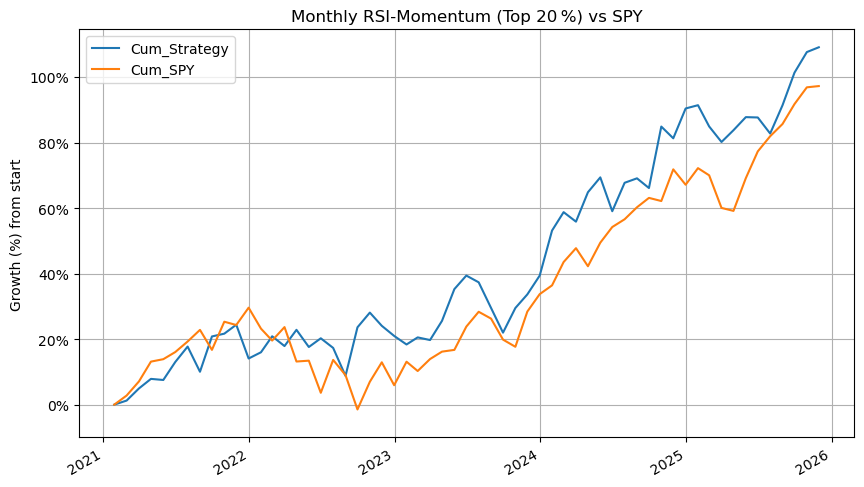

In [65]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(10,6))
perf_pct.plot(ax=ax)

ax.set_ylim(-10, perf_pct.max().max()*1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("Growth (%) from start")
ax.set_title("Monthly RSI-Momentum (Top 20 %) vs SPY")
ax.grid(True)
plt.show()

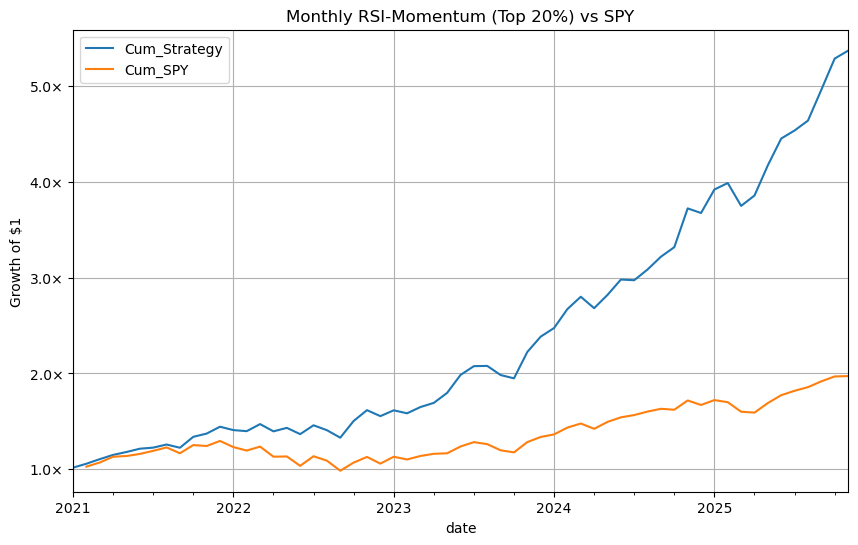

In [112]:
# ── 5) plot
fig, ax = plt.subplots(figsize=(10,6))
perf[['Cum_Strategy','Cum_SPY']].plot(ax=ax)
ax.set_title("Monthly RSI-Momentum (Top 20%) vs SPY")
ax.set_ylabel("Growth of $1")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.1f}×"))
ax.grid(True)
plt.show()

#### Strategy Statistics

In [67]:
def perf_stats(returns, rf=0.0, freq=12):
    """
    returns : pd.Series of strategy *monthly* returns
    rf      : risk-free rate per period (0 means excess return = return)
    """
    excess = returns - rf
    # Annualisation factor
    ann = np.sqrt(freq)
    
    stats = {
        "CAGR": (1 + returns).prod()**(freq / len(returns)) - 1,
        "Annualised Vol":  excess.std(ddof=0) * ann,
        "Sharpe":          excess.mean() / excess.std(ddof=0) * ann,
        "Max Drawdown":    (1 + returns).cumprod().div((1 + returns).cumprod().cummax()).min() - 1,
        "Hit Ratio":       (returns > 0).mean(),
    }
    return pd.Series(stats)

# example
stats_strategy = perf_stats(perf['Strategy'])
stats_spy       = perf_stats(perf['SPY'])
display(pd.concat({"Strategy": stats_strategy, "SPY": stats_spy}, axis=1))


,Strategy,SPY
CAGR,0.164861,0.150892
Annualised Vol,0.158995,0.154210
Sharpe,1.044165,0.994143
Max Drawdown,-0.125572,-0.239722
Hit Ratio,0.620690,0.672414


In [68]:
strategy_monthly.tail()

,Strategy
date,
2025-07-31,-0.026140
2025-08-31,0.047237
2025-09-30,0.051977
2025-10-31,0.031236
2025-11-30,0.007060


In [69]:
strat1_ff5 = (
    strategy_monthly
      .join(ff5, how="inner")   # only keep months common to both
      .dropna()
)
strat1_ff5.tail()

,Strategy,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,,
2025-07-31,-0.026140,0.0198,-0.0014,-0.0127,-0.0028,-0.0207,0.0034
2025-08-31,0.047237,0.0185,0.0488,0.0442,-0.0069,0.0208,0.0038
2025-09-30,0.051977,0.0339,-0.0218,-0.0105,-0.0205,-0.0222,0.0033
2025-10-31,0.031236,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0037
2025-11-30,0.007060,-0.0013,0.0147,0.0376,0.0144,0.0068,0.0030


In [70]:
strat1_ff5["Excess"] = strat1_ff5["Strategy"] - strat1_ff5["RF"]
strat1_ff5.tail()

,Strategy,Mkt-RF,SMB,HML,RMW,CMA,RF,Excess
date,,,,,,,,
2025-07-31,-0.026140,0.0198,-0.0014,-0.0127,-0.0028,-0.0207,0.0034,-0.029540
2025-08-31,0.047237,0.0185,0.0488,0.0442,-0.0069,0.0208,0.0038,0.043437
2025-09-30,0.051977,0.0339,-0.0218,-0.0105,-0.0205,-0.0222,0.0033,0.048677
2025-10-31,0.031236,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0037,0.027536
2025-11-30,0.007060,-0.0013,0.0147,0.0376,0.0144,0.0068,0.0030,0.004060


In [71]:
import statsmodels.api as sm

# 1) Define the “X” matrix of predictors (add a constant for the intercept)
X = strat1_ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
X = sm.add_constant(X)   # insert a column called “const” = 1

# 2) The dependent variable is the excess return
y = strat1_ff5["Excess"]

# 3) Fit OLS
model = sm.OLS(endog=y, exog=X)
results = model.fit(cov_type="HC0")   # HC0 = White’s robust (optional)
                                       # You can also omit cov_type for classic
print(results.summary())

# 4) Intercept (alpha) and its p-value
alpha     = results.params["const"]
alpha_p   = results.pvalues["const"]

# 5) Factor betas and their p‐values
betas     = results.params.drop("const")        # a Series indexed by Mkt-RF, SMB, HML, RMW, CMA
p_values  = results.pvalues.drop("const")

print("\nAlpha (intercept) = {:.6f},  p-value = {:.6f}".format(alpha, alpha_p))
print("\nFactor    Beta    p-value")
for factor in betas.index:
    print(f"  {factor:<6}  {betas[factor]: .6f}  {p_values[factor]: .6f}")

                            OLS Regression Results                            
Dep. Variable:                 Excess   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                 -0.044
Method:                 Least Squares   F-statistic:                    0.4093
Date:                Thu, 09 Apr 2026   Prob (F-statistic):              0.840
Time:                        11:50:57   Log-Likelihood:                 99.208
No. Observations:                  59   AIC:                            -186.4
Df Residuals:                      53   BIC:                            -174.0
Df Model:                           5                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0126      0.007      1.833      0.0

In [72]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# --- Use the same dataframe ---
df = strat1_ff5.copy()

# --- Clean column names ---
df.columns = df.columns.str.strip()

# --- Rename Mkt-RF → Mkt_RF ---
df = df.rename(columns={"Mkt-RF": "Mkt_RF"})

# --- Run regression ---
formula = 'Excess ~ Mkt_RF + SMB + HML + RMW + CMA'

model_f = smf.ols(formula, data=df).fit(cov_type="HC0")

anova_results = anova_lm(model_f, typ=1)
print(anova_results)

            df    sum_sq   mean_sq         F    PR(>F)
Mkt_RF     1.0  0.003402  0.003402  1.507147  0.225000
SMB        1.0  0.000039  0.000039  0.017478  0.895323
HML        1.0  0.000926  0.000926  0.410082  0.524687
RMW        1.0  0.000630  0.000630  0.279122  0.599483
CMA        1.0  0.000805  0.000805  0.356856  0.552801
Residual  53.0  0.119632  0.002257       NaN       NaN


### 6.2 Cross-Sectional Multi-Factor Composite Rank 
Testing a signal that incorporates normalizing a dozen technical/fundamental factors for our top 100 most liquid S&P 500 stocks each month, summing the z-scores into a composite rank, and holding a max-Sharpe-weighted basket of the top 20% stocks, rebalanced each month.

In [73]:
data = data_final.copy()
data.head()

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2021-01-31 AAPL           -0.000047  55.031858  4.791687  4.869626  4.947565   
           ABBV           -0.016064  53.220607  4.438002  4.499895  4.561787   
           ABT            -0.000740  61.517399  4.575871  4.640939  4.706006   
           ADBE            0.000210  48.966684  6.113214  6.159311  6.205408   
           AMAT           -0.001510  59.153949  4.416194  4.563585  4.710976   

                         atr      macd  return1m  return2m  return3m  \
date       ticker                                                      
2021-01-31 AAPL     4.319293  2.825904 -0.005502  0.052826  0.066860   
           ABBV     2.527208  0.447213 -0.032398 -0.004319  0.068038   
           ABT      3.070299  2.459832  0.133326  0.070806  0.056887   
           ADBE    11.848018 -5.401558 -0.082680 -0.020803  0.008626   
           AMAT     4.017565  3.765242  0.120278  0.082665  0.172317   

                   return6m  return9m  return12m     fwd1m    Mkt-RF  \
date       ticker                                                      
2021-01-31 AAPL    0.037371  0.068004   0.046237 -0.079712  1.215333   
           ABBV    0.017127  0.029058   0.024210  0.051327  0.556689   
           ABT     0.036098  0.034519   0.030874 -0.030828  0.737388   
           ADBE    0.005348  0.029341   0.022530  0.001962  0.825984   
           AMAT    0.071376  0.078011   0.044681  0.224807  1.323630   

                        SMB       HML       RMW       CMA         RF  
date       ticker                                                     
2021-01-31 AAPL   -0.324493 -0.459091  1.619847  1.871488   6.283715  
           ABBV    2.473314 -0.961833  0.936622  0.704947  80.277426  
           ABT    -1.077349 -0.231646  0.345303  0.582771 -42.723985  
           ADBE    0.718382 -0.877306  1.614042 -0.080033  46.171049  
           AMAT    1.116064 -0.069116 -2.459365 -0.093649  23.739539

In [74]:
from scipy import stats

factors   = ['rsi', 'macd', 'atr', 'bb_high', 'bb_low', 'bb_mid',
             'garman_klass_vol', 'Mkt-RF', 'SMB', 'HML', 'CMA', 'RMW']

# --- helper: z-score each factor cross-sectionally -----------------
def zscore_cross(df):
    return df.sub(df.mean()).div(df.std(ddof=0))

# ---------------------------------------------------------------
#  A)  Rank-sum composite (simple & robust)
# ---------------------------------------------------------------
def rank_sum_score(data):
    def make_score(one_day):
        z = zscore_cross(one_day[factors])
        return z.sum(axis=1)                         # ticker × 1
    return (data
            .groupby(level='date', group_keys=False)
            .apply(make_score)
            .rename('rank_sum'))

In [75]:
data = data.join(rank_sum_score(data))
data.tail()

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2025-11-30 VZ              0.000013  49.685573  3.676507  3.708847  3.741187   
           WFC             0.000097  54.588171  4.422074  4.452053  4.482033   
           WMT             0.000101  57.864818  4.594510  4.646324  4.698137   
           XOM             0.000562  53.267504  4.719380  4.755904  4.792427   
           XYZ             0.000343  47.607309  4.041241  4.197226  4.353212   

                        atr      macd  return1m  return2m  return3m  ...  \
date       ticker                                                    ...   
2025-11-30 VZ      0.731857  0.120852  0.034474 -0.024572 -0.018529  ...   
           WFC     2.076489  0.188738 -0.007688  0.014694  0.016445  ...   
           WMT     2.349481  1.177636  0.092212  0.035513  0.044495  ...   
           XOM     2.253518  0.617339  0.022507  0.018385  0.007652  ...   
           XYZ     2.998434 -2.798336 -0.120358 -0.038589 -0.056920  ...   

                   return9m  return12m     fwd1m    Mkt-RF       SMB  \
date       ticker                                                      
2025-11-30 VZ      0.000194  -0.000754 -0.009973  0.456011  0.320709   
           WFC     0.012114   0.011830  0.098544  1.742552 -0.591484   
           WMT     0.013583   0.015756  0.014823  1.210179 -0.684990   
           XOM     0.007533   0.001551  0.043737  0.308399  0.612367   
           XYZ     0.002527  -0.023215 -0.018862  0.886613  2.828422   

                        HML       RMW       CMA          RF  rank_sum  
date       ticker                                                      
2025-11-30 VZ      1.357314  0.561231 -0.058030  -70.577245 -5.801239  
           WFC     1.252225 -0.523955 -0.646091   94.469446 -2.431508  
           WMT     0.606935 -0.059040 -1.146470   53.039303 -2.220019  
           XOM     1.048682 -0.078728  0.148468 -105.229146  1.566403  
           XYZ    -1.986125  0.223536 -1.278662   28.264084 -3.705077  

[5 rows x 21 columns]

In [76]:
rebalance_dates_rs = {}
top_quantile = 0.2

for dt, day in data.groupby(level='date', group_keys=False):
    # 1) z-score each factor within the cross-section
    z = zscore_cross(day[factors])
    # 2) sum z-scores → composite rank
    rank_sum = z.sum(axis=1)

    N = int(len(rank_sum) * top_quantile)
    if N == 0:
        continue

    # 3) grab tickers as a plain *list* (not an Index!)
    top = (rank_sum.nlargest(N)
           .index.get_level_values('ticker')
           .tolist())

    rebalance_dates_rs[dt] = top

# Inspecting the results
for d, tickers in list(rebalance_dates_rs.items())[:3]:
    print(d, tickers[:5], "...", len(tickers), "tickers")

2021-01-31 00:00:00 ['TSLA', 'TMO', 'LLY', 'MSFT', 'CHTR'] ... 17 tickers
2021-02-28 00:00:00 ['TSLA', 'XYZ', 'GS', 'MA', 'CRM'] ... 17 tickers
2021-03-31 00:00:00 ['TSLA', 'ELV', 'META', 'BA', 'UNH'] ... 17 tickers


In [77]:
from curl_cffi import requests
session = requests.Session(impersonate="chrome")

price_hist = {}
for date, tickers in rebalance_dates_rs.items():
    start = (pd.to_datetime(date) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
    end = (pd.to_datetime(date) - pd.DateOffset(days=1)).strftime('%Y-%m-%d')

    symbols = tickers

    df = (
        yf.download(
            tickers = symbols,
            start = start,
            end = end,
            session = session,
            auto_adjust = False,
            progress = False
        )['Adj Close']
    )
    price_hist[date] = df

list(price_hist.items())[:2]


1 Failed download:
['TSLA']: TypeError("'NoneType' object is not subscriptable")


[(Timestamp('2021-01-31 00:00:00'),
  Ticker            AAPL        ADBE        AMZN        BIIB        CHTR  \
  Date                                                                     
  2020-01-31   74.608574  351.140015  100.435997  268.850006  517.460022   
  2020-02-03   74.403671  358.000000  100.209999  272.730011  532.049988   
  2020-02-04   76.860008  366.739990  102.483498  283.290009  531.750000   
  2020-02-05   77.486748  365.549988  101.993500  332.869995  522.179993   
  2020-02-06   78.393120  367.459991  102.511497  337.239990  526.559998   
  ...                ...         ...         ...         ...         ...   
  2021-01-25  138.995743  473.440002  164.699997  275.540009  652.169983   
  2021-01-26  139.229156  476.279999  166.306503  271.670013  649.539978   
  2021-01-27  138.159332  460.000000  161.628998  265.149994  615.780029   
  2021-01-28  133.325806  465.670013  161.880997  267.869995  654.650024   
  2021-01-29  128.336685  458.769989  160.309998  28

In [78]:
# ── 2) build a monthly Series of strategy returns (weighted by max-Sharpe, unless facing errors)
strategy_rows = []

for dt, tickers in rebalance_dates_rs.items():
    # 2a) Next‐month returns from your factor table
    cross = data.xs(dt, level='date')
    rets1 = cross.loc[tickers, 'fwd1m']     # Series indexed by ticker

    # 2b) Grab the already‐downloaded last 12 m prices from price_hist:
    price_df = price_hist[dt].copy()[tickers]  # select only our tickers
    # drop any symbols that had no data at all
    price_df = price_df.dropna(axis=1, how='all')

    # 2c) solve for max‐Sharpe weights (fallback to equal‐weight)
    try:
        wdict = optimize_weights(price_df)
        w = pd.Series(wdict)
    except Exception as e:
        print(f"⚠️  Optimization failed on {dt}: {e}")
        w = pd.Series(1 / len(tickers), index=tickers)

    # 2d) portfolio return = Σ wᵢ · return1mᵢ
    port_ret = (w * rets1).sum()
    strategy_rows.append({'date': dt, 'Strategy': port_ret})

strategy_monthly2 = (
    pd.DataFrame(strategy_rows)
      .set_index('date')
      .sort_index()
)
strategy_monthly2.head()

,Strategy
date,
2021-01-31,-0.044383
2021-02-28,0.001623
2021-03-31,0.059201
2021-04-30,-0.004996
2021-05-31,0.011585


In [79]:
# ── 3) grab SPY monthly returns from yfinance on the same calendar
spy_monthly = yf.download(
    tickers=['SPY'],
    start=strategy_monthly2.index.min() - pd.DateOffset(months=1),
    end  =strategy_monthly2.index.max() + pd.DateOffset(days=1),
    interval='1mo',
    auto_adjust=False, progress=False
)['Adj Close']

# align to month-end
spy_monthly.index = (
    pd.to_datetime(spy_monthly.index)
      .to_period('M')
      .to_timestamp('M')
)

# compute 1-month returns, then select only our rebalance dates
spy_ret = spy_monthly.pct_change().dropna()
spy_ret.tail()

Ticker,SPY
Date,
2025-07-31,0.026056
2025-08-31,0.020520
2025-09-30,0.032757
2025-10-31,0.026676
2025-11-30,0.001950


In [80]:
# ── 4) merge and cumulate
perf = strategy_monthly2.join(spy_ret, how='inner')

perf['Cum_Strategy'] = (1 + perf['Strategy']).cumprod()
perf['Cum_SPY']      = (1 + perf['SPY']).cumprod()
perf.tail()

,Strategy,SPY,Cum_Strategy,Cum_SPY
2025-07-31,-0.031382,0.026056,1.147403,1.819286
2025-08-31,0.038491,0.020520,1.191568,1.856617
2025-09-30,0.021296,0.032757,1.216943,1.917435
2025-10-31,0.036918,0.026676,1.261870,1.968584
2025-11-30,0.021953,0.001950,1.289572,1.972423


In [81]:
# 1) percent growth from the Cum_ columns
perf_pct = (perf[['Cum_Strategy','Cum_SPY']] - 1) * 100

# 2) insert a zero‐row one period before the first date
first = perf_pct.index.min()
start = first - pd.DateOffset(months=1)
zero_row = pd.DataFrame([[0.0, 0.0]],
                        index=[start],
                        columns=perf_pct.columns)

perf_pct = pd.concat([zero_row, perf_pct]).sort_index()

# now perf_pct.iloc[0] == 0 for both, and
# perf_pct.iloc[-1] should be ~184 vs ~119
perf_pct.tail()

,Cum_Strategy,Cum_SPY
2025-07-31,14.740344,81.928646
2025-08-31,19.156778,85.661737
2025-09-30,21.694295,91.743485
2025-10-31,26.186993,96.858408
2025-11-30,28.957224,97.242289


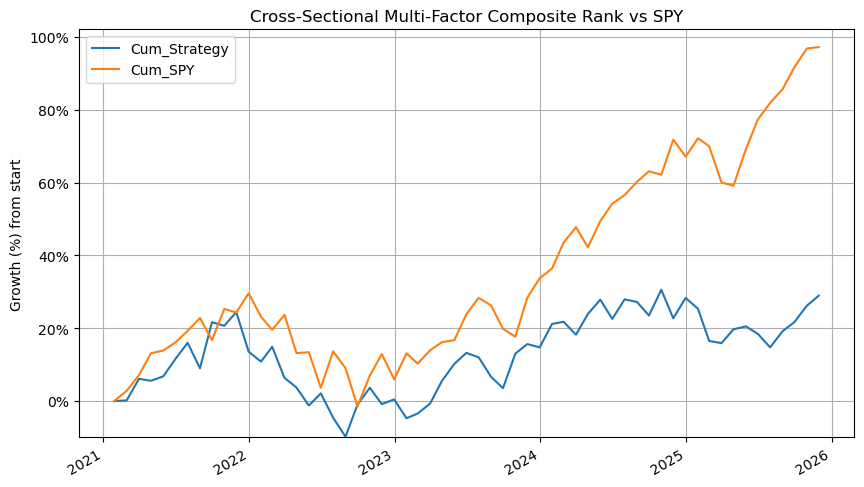

In [82]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(10,6))
perf_pct.plot(ax=ax)

ax.set_ylim(-10, perf_pct.max().max()*1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("Growth (%) from start")
ax.set_title("Cross-Sectional Multi-Factor Composite Rank vs SPY")
ax.grid(True)
plt.show()

#### Strategy Statistics

In [83]:
def perf_stats(returns, rf=0.0, freq=12):
    """
    returns : pd.Series of strategy *monthly* returns
    rf      : risk-free rate per period (0 means excess return = return)
    """
    excess = returns - rf
    # Annualisation factor
    ann = np.sqrt(freq)
    
    stats = {
        "CAGR": (1 + returns).prod()**(freq / len(returns)) - 1,
        "Annualised Vol":  excess.std(ddof=0) * ann,
        "Sharpe":          excess.mean() / excess.std(ddof=0) * ann,
        "Max Drawdown":    (1 + returns).cumprod().div((1 + returns).cumprod().cummax()).min() - 1,
        "Hit Ratio":       (returns > 0).mean(),
    }
    return pd.Series(stats)

stats_strategy = perf_stats(perf['Strategy'])
stats_spy       = perf_stats(perf['SPY'])
display(pd.concat({"Strategy": stats_strategy, "SPY": stats_spy}, axis=1))

,Strategy,SPY
CAGR,0.054025,0.150892
Annualised Vol,0.156964,0.154210
Sharpe,0.414081,0.994142
Max Drawdown,-0.275214,-0.239722
Hit Ratio,0.551724,0.672414


#### FF5 Model Regression Analysis against Portfolio 6.2

In [84]:
strategy_monthly2.head()

,Strategy
date,
2021-01-31,-0.044383
2021-02-28,0.001623
2021-03-31,0.059201
2021-04-30,-0.004996
2021-05-31,0.011585


In [85]:
strat2_ff5 = (
    strategy_monthly2
      .join(ff5, how="inner")   # only keep months common to both
      .dropna()
)
strat2_ff5.tail()

,Strategy,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,,
2025-07-31,-0.031382,0.0198,-0.0014,-0.0127,-0.0028,-0.0207,0.0034
2025-08-31,0.038491,0.0185,0.0488,0.0442,-0.0069,0.0208,0.0038
2025-09-30,0.021296,0.0339,-0.0218,-0.0105,-0.0205,-0.0222,0.0033
2025-10-31,0.036918,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0037
2025-11-30,0.021953,-0.0013,0.0147,0.0376,0.0144,0.0068,0.0030


In [86]:
strat2_ff5["Excess"] = strat2_ff5["Strategy"] - strat2_ff5["RF"]
strat2_ff5.tail()

,Strategy,Mkt-RF,SMB,HML,RMW,CMA,RF,Excess
date,,,,,,,,
2025-07-31,-0.031382,0.0198,-0.0014,-0.0127,-0.0028,-0.0207,0.0034,-0.034782
2025-08-31,0.038491,0.0185,0.0488,0.0442,-0.0069,0.0208,0.0038,0.034691
2025-09-30,0.021296,0.0339,-0.0218,-0.0105,-0.0205,-0.0222,0.0033,0.017996
2025-10-31,0.036918,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0037,0.033218
2025-11-30,0.021953,-0.0013,0.0147,0.0376,0.0144,0.0068,0.0030,0.018953


In [87]:
import statsmodels.api as sm

# 1) Define the “X” matrix of predictors (add a constant for the intercept)
X = strat2_ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
X = sm.add_constant(X)   # insert a column called “const” = 1

# 2) The dependent variable is the excess return
y = strat2_ff5["Excess"]

# 3) Fit OLS
model = sm.OLS(endog=y, exog=X)
results = model.fit(cov_type="HC0")   # HC0 = White’s robust (optional)
                                       # You can also omit cov_type for classic
print(results.summary())

# 4) Intercept (alpha) and its p-value
alpha     = results.params["const"]
alpha_p   = results.pvalues["const"]

# 5) Factor betas and their p‐values
betas     = results.params.drop("const")        # a Series indexed by Mkt-RF, SMB, HML, RMW, CMA
p_values  = results.pvalues.drop("const")

print("\nAlpha (intercept) = {:.6f},  p-value = {:.6f}".format(alpha, alpha_p))
print("\nFactor    Beta    p-value")
for factor in betas.index:
    print(f"  {factor:<6}  {betas[factor]: .6f}  {p_values[factor]: .6f}")

                            OLS Regression Results                            
Dep. Variable:                 Excess   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.253
Date:                Thu, 09 Apr 2026   Prob (F-statistic):              0.298
Time:                        11:51:30   Log-Likelihood:                 101.64
No. Observations:                  59   AIC:                            -191.3
Df Residuals:                      53   BIC:                            -178.8
Df Model:                           5                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0050      0.006      0.845      0.3

Alpha is not significant (p-value = 0.398 > 0.05), as this backtested strategy does not deliver a significant positive intercept above the FF risk premiums (~0.5%) i.e. 'true alpha'.

### 6.3 Rolling-IC-Weighted Composite Signal
Testing a signal that computes every technical/fundamental factor's 24-month information coefficient with next-month returns, scaling today's cross-sectional z-scores by those ICs, summing the results into an adaptive composite score, and trading the stocks with the top 20% of scores.

In [88]:
# ---------------------------------------------------------------
#  B)  IC-weighted composite (rolling 24-month window)
# ---------------------------------------------------------------
def ic_weighted_score(data, fwd_col='fwd1m', window=24):
    # 1) daily (monthly) IC per factor
    def daily_ic(one_day):
        return {f: one_day[f].corr(one_day[fwd_col]) for f in factors}
    ic = (data
          .groupby(level='date', group_keys=False)
          .apply(daily_ic)
          .apply(pd.Series)                   # date × factor
          .rolling(window, min_periods=12)
          .mean())                            # 24-period rolling IC
    
    # 2) z-scores for each factor
    z = (data
         .groupby(level='date', group_keys=False)
         .apply(lambda d: zscore_cross(d[factors]))
    )
    
    # 3) multiply z by IC weight of that day
    def weighted(one_day):
        w = ic.loc[one_day.name]
        return (one_day[factors] * w).sum(axis=1)
    return z.groupby(level='date', group_keys=False).apply(weighted).rename('ic_weighted')

In [89]:
data = data.join(ic_weighted_score(data))
data.head()

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2021-01-31 AAPL           -0.000047  55.031858  4.791687  4.869626  4.947565   
           ABBV           -0.016064  53.220607  4.438002  4.499895  4.561787   
           ABT            -0.000740  61.517399  4.575871  4.640939  4.706006   
           ADBE            0.000210  48.966684  6.113214  6.159311  6.205408   
           AMAT           -0.001510  59.153949  4.416194  4.563585  4.710976   

                         atr      macd  return1m  return2m  return3m  ...  \
date       ticker                                                     ...   
2021-01-31 AAPL     4.319293  2.825904 -0.005502  0.052826  0.066860  ...   
           ABBV     2.527208  0.447213 -0.032398 -0.004319  0.068038  ...   
           ABT      3.070299  2.459832  0.133326  0.070806  0.056887  ...   
           ADBE    11.848018 -5.401558 -0.082680 -0.020803  0.008626  ...   
           AMAT     4.017565  3.765242  0.120278  0.082665  0.172317  ...   

                   return12m     fwd1m    Mkt-RF       SMB       HML  \
date       ticker                                                      
2021-01-31 AAPL     0.046237 -0.079712  1.215333 -0.324493 -0.459091   
           ABBV     0.024210  0.051327  0.556689  2.473314 -0.961833   
           ABT      0.030874 -0.030828  0.737388 -1.077349 -0.231646   
           ADBE     0.022530  0.001962  0.825984  0.718382 -0.877306   
           AMAT     0.044681  0.224807  1.323630  1.116064 -0.069116   

                        RMW       CMA         RF  rank_sum  ic_weighted  
date       ticker                                                        
2021-01-31 AAPL    1.619847  1.871488   6.283715  4.704219          0.0  
           ABBV    0.936622  0.704947  80.277426 -0.997852          0.0  
           ABT     0.345303  0.582771 -42.723985  1.854031          0.0  
           ADBE    1.614042 -0.080033  46.171049  5.874041          0.0  
           AMAT   -2.459365 -0.093649  23.739539  2.338679          0.0  

[5 rows x 22 columns]

In [90]:
# -------------------------------------------------------
# 1)  Pre-compute rolling 24-month IC for every factor
# -------------------------------------------------------
window = 24                     # months
fwd    = 'fwd1m'                # future return column
factors = ['rsi','macd','atr','bb_high','bb_low','bb_mid',
           'garman_klass_vol','Mkt-RF','SMB','HML','CMA','RMW']

def daily_ic(one_day):
    return {f : one_day[f].corr(one_day[fwd]) for f in factors}

# date × factor DataFrame of daily ICs
ic_df = (data
         .groupby(level='date', group_keys=False)
         .apply(daily_ic)
         .apply(pd.Series))

# 24-month rolling mean IC
ic_roll = ic_df.rolling(window, min_periods=12).mean()

# -------------------------------------------------------
# 2)  Build rebalance_dates dict using IC-weighted rank
# -------------------------------------------------------
top_quantile = 0.2
rebalance_dates_ic = {}

for dt, day in data.groupby(level='date', group_keys=False):
    w = ic_roll.loc[dt]                       # weight vector today
    z = zscore_cross(day[factors])            # z-scores
    ic_weighted_score = (z * w).sum(axis=1)   # ticker × 1

    N = int(len(ic_weighted_score)*top_quantile)
    if N == 0:
        continue

    top = (ic_weighted_score.nlargest(N)
           .index.get_level_values('ticker')
           .tolist())

    rebalance_dates_ic[dt] = top

for d, t in list(rebalance_dates_ic.items())[:3]:
    print(d, t[:5], '...', len(t))

2021-01-31 00:00:00 ['AAPL', 'ABBV', 'ABT', 'ADBE', 'AMAT'] ... 17
2021-02-28 00:00:00 ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE'] ... 17
2021-03-31 00:00:00 ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE'] ... 17


In [91]:
from curl_cffi import requests
session = requests.Session(impersonate="chrome")

price_hist = {}
for date, tickers in rebalance_dates.items():
    start = (pd.to_datetime(date) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
    end = (pd.to_datetime(date) - pd.DateOffset(days=1)).strftime('%Y-%m-%d')

    symbols = tickers

    df = (
        yf.download(
            tickers = symbols,
            start = start,
            end = end,
            session = session,
            auto_adjust = False,
            progress = False
        )['Adj Close']
    )
    price_hist[date] = df

list(price_hist.items())[:2]

[(Timestamp('2021-01-31 00:00:00'),
  Ticker             ABT        AMAT       AVGO        CMG         DD  \
  Date                                                                  
  2020-01-31   78.315132   54.726398  26.198286  17.335199  18.943649   
  2020-02-03   78.243210   56.359035  26.204290  17.346600  19.176832   
  2020-02-04   79.294724   59.463875  26.751162  17.696400  19.506260   
  2020-02-05   80.490051   60.209408  27.247381  17.080200  20.017040   
  2020-02-06   80.409149   59.633743  27.445696  17.139999  19.917110   
  ...                ...         ...        ...        ...        ...   
  2021-01-25  104.704697  103.411629  41.725323  29.726400  30.795998   
  2021-01-26  104.713821  100.934418  41.642738  29.785000  30.220587   
  2021-01-27  104.312218   94.287056  39.921799  29.327200  29.489958   
  2021-01-28  109.879700   96.745163  40.553795  29.610800  30.708925   
  2021-01-29  112.800331   92.469803  40.442478  29.600000  30.076725   
  
  Ticker    

In [92]:
# 2) build a monthly Series of strategy returns (weighted by max-Sharpe, unless facing errors)
strategy_rows = []

for dt, tickers in rebalance_dates.items():
    # 2a) Next‐month returns from your factor table
    cross = data.xs(dt, level='date')
    rets1 = cross.loc[tickers, 'fwd1m']     # Series indexed by ticker

    # 2b) Grab the already‐downloaded last 12 m prices from price_hist:
    price_df = price_hist[dt].copy()[tickers]  # select only our tickers
    # drop any symbols that had no data at all
    price_df = price_df.dropna(axis=1, how='all')

    # 2c) solve for max‐Sharpe weights (fallback to equal‐weight)
    try:
        wdict = optimize_weights(price_df)
        w = pd.Series(wdict)
    except Exception as e:
        print(f"⚠️  Optimization failed on {dt}: {e}")
        w = pd.Series(1 / len(tickers), index=tickers)

    # 2d) portfolio return = Σ wᵢ · return1mᵢ
    port_ret = (w * rets1).sum()
    strategy_rows.append({'date': dt, 'Strategy': port_ret})

strategy_monthly3 = (
    pd.DataFrame(strategy_rows)
      .set_index('date')
      .sort_index()
)
strategy_monthly3.head()

,Strategy
date,
2021-01-31,-0.049684
2021-02-28,0.012409
2021-03-31,0.036652
2021-04-30,0.027733
2021-05-31,-0.003094


In [93]:
# ── 3) grab SPY monthly returns from yfinance on the same calendar
spy_monthly = yf.download(
    tickers=['SPY'],
    start=strategy_monthly3.index.min() - pd.DateOffset(months=1),
    end  =strategy_monthly3.index.max() + pd.DateOffset(days=1),
    interval='1mo',
    auto_adjust=False, progress=False
)['Adj Close']

# align to month-end
spy_monthly.index = (
    pd.to_datetime(spy_monthly.index)
      .to_period('M')
      .to_timestamp('M')
)

# compute 1-month returns, then select only our rebalance dates
spy_ret = spy_monthly.pct_change().dropna()
spy_ret.tail()

Ticker,SPY
Date,
2025-07-31,0.026056
2025-08-31,0.020520
2025-09-30,0.032757
2025-10-31,0.026676
2025-11-30,0.001950


In [94]:
# 4) merge and cumulate
perf = strategy_monthly3.join(spy_ret, how='inner')

perf['Cum_Strategy'] = (1 + perf['Strategy']).cumprod()
perf['Cum_SPY']      = (1 + perf['SPY']).cumprod()
perf.tail()

,Strategy,SPY,Cum_Strategy,Cum_SPY
2025-07-31,-0.026138,0.026056,1.827524,1.819286
2025-08-31,0.047237,0.020520,1.913851,1.856617
2025-09-30,0.051977,0.032757,2.013327,1.917435
2025-10-31,0.031236,0.026676,2.076215,1.968584
2025-11-30,0.007060,0.001950,2.090873,1.972423


In [95]:
# 1) percent growth from the Cum_ columns
perf_pct = (perf[['Cum_Strategy','Cum_SPY']] - 1) * 100

# 2) insert a zero‐row one period before the first date
first = perf_pct.index.min()
start = first - pd.DateOffset(months=1)
zero_row = pd.DataFrame([[0.0, 0.0]],
                        index=[start],
                        columns=perf_pct.columns)

perf_pct = pd.concat([zero_row, perf_pct]).sort_index()

# now perf_pct.iloc[0] == 0 for both, and
# perf_pct.iloc[-1] should be ~184 vs ~119
perf_pct.tail()

,Cum_Strategy,Cum_SPY
2025-07-31,82.752358,81.928630
2025-08-31,91.385079,85.661721
2025-09-30,101.332674,91.743468
2025-10-31,107.621512,96.858391
2025-11-30,109.087291,97.242271


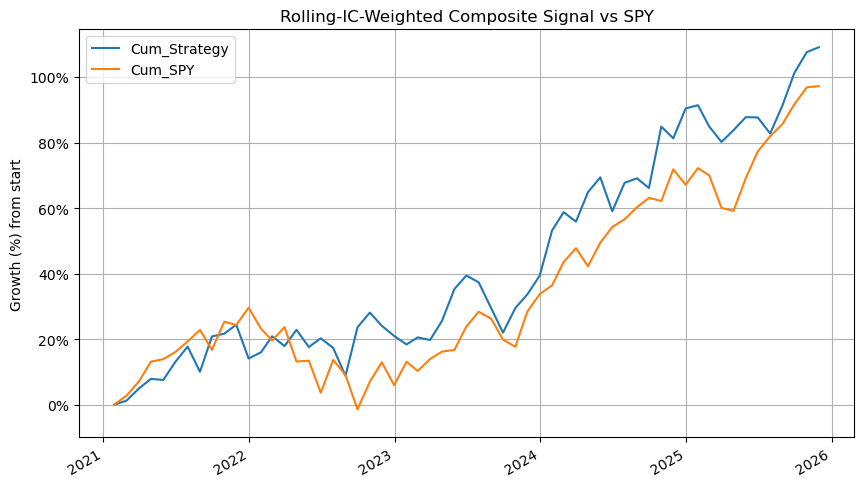

In [96]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(10,6))
perf_pct.plot(ax=ax)

ax.set_ylim(-10, perf_pct.max().max()*1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("Growth (%) from start")
ax.set_title("Rolling-IC-Weighted Composite Signal vs SPY")
ax.grid(True)
plt.show()

#### Strategy Statistics

In [97]:
def perf_stats(returns, rf=0.0, freq=12):
    """
    returns : pd.Series of strategy *monthly* returns
    rf      : risk-free rate per period (0 means excess return = return)
    """
    excess = returns - rf
    # Annualisation factor
    ann = np.sqrt(freq)
    
    stats = {
        "CAGR": (1 + returns).prod()**(freq / len(returns)) - 1,
        "Annualised Vol":  excess.std(ddof=0) * ann,
        "Sharpe":          excess.mean() / excess.std(ddof=0) * ann,
        "Max Drawdown":    (1 + returns).cumprod().div((1 + returns).cumprod().cummax()).min() - 1,
        "Hit Ratio":       (returns > 0).mean(),
    }
    return pd.Series(stats)

stats_strategy = perf_stats(perf['Strategy'])
stats_spy       = perf_stats(perf['SPY'])
display(pd.concat({"Strategy": stats_strategy, "SPY": stats_spy}, axis=1))

,Strategy,SPY
CAGR,0.164863,0.150892
Annualised Vol,0.158995,0.154210
Sharpe,1.044174,0.994142
Max Drawdown,-0.125570,-0.239722
Hit Ratio,0.620690,0.672414


In [98]:
import ffn

# Keep only return columns
returns = perf[['Strategy', 'SPY']]

def ffn_stats(returns_series):
    stats = ffn.core.PerformanceStats(returns_series)
    
    # For monthly returns, annualize vol and Sharpe
    annual_vol = stats.stats['daily_vol'] * (12**0.5)  # monthly -> annualized
    annual_sharpe = stats.stats['daily_sharpe'] * (12**0.5)
    
    return pd.Series({
        "CAGR":            stats.stats['cagr'],
        "Annualised Vol":  annual_vol,
        "Sharpe":          annual_sharpe,
        "Max Drawdown":    stats.stats['max_drawdown'],
        "Calmar":          stats.stats['cagr'] / abs(stats.stats['max_drawdown']) if stats.stats['max_drawdown'] != 0 else float('nan'),
        "Hit Ratio":       (returns_series > 0).mean()
    })

# Compute stats for each series
all_stats = pd.concat({col: ffn_stats(returns[col]) for col in returns.columns}, axis=1)

# Display nicely as percentages
display(all_stats.style.format("{:+.2%}"))

,Strategy,SPY
CAGR,-11.19%,-42.83%
Annualised Vol,+nan%,+nan%
Sharpe,+nan%,+nan%
Max Drawdown,-227.97%,-217.41%
Calmar,-4.91%,-19.70%
Hit Ratio,+62.07%,+67.24%


#### FF5 Model Regression Analysis against Portfolio 6.3

In [99]:
strat3_ff5 = (
    strategy_monthly3
      .join(ff5, how="inner")   # only keep months common to both
      .dropna()
)
strat3_ff5.head()

,Strategy,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,,
2021-01-31,-0.049684,-0.0007,0.0681,0.0322,-0.0365,0.0497,0.0
2021-02-28,0.012409,0.0281,0.0450,0.0720,0.0033,-0.0199,0.0
2021-03-31,0.036652,0.0316,-0.0084,0.0735,0.0635,0.0352,0.0
2021-04-30,0.027733,0.0497,-0.0316,-0.0102,0.0243,-0.0272,0.0
2021-05-31,-0.003094,0.0029,0.0127,0.0704,0.0234,0.0301,0.0


In [100]:
strat3_ff5["Excess"] = strat3_ff5["Strategy"] - strat3_ff5["RF"]
strat3_ff5.tail()

,Strategy,Mkt-RF,SMB,HML,RMW,CMA,RF,Excess
date,,,,,,,,
2025-07-31,-0.026138,0.0198,-0.0014,-0.0127,-0.0028,-0.0207,0.0034,-0.029538
2025-08-31,0.047237,0.0185,0.0488,0.0442,-0.0069,0.0208,0.0038,0.043437
2025-09-30,0.051977,0.0339,-0.0218,-0.0105,-0.0205,-0.0222,0.0033,0.048677
2025-10-31,0.031236,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0037,0.027536
2025-11-30,0.007060,-0.0013,0.0147,0.0376,0.0144,0.0068,0.0030,0.004060


In [101]:
import statsmodels.api as sm

# 1) Define the “X” matrix of predictors (add a constant for the intercept)
X = strat3_ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
X = sm.add_constant(X)   # insert a column called “const” = 1

# 2) The dependent variable is the excess return
y = strat3_ff5["Excess"]

# 3) Fit OLS
model = sm.OLS(endog=y, exog=X)
results = model.fit(cov_type="HC0")   # HC0 = White’s robust (optional)
                                       # You can also omit cov_type for classic
print(results.summary())

# 4) Intercept (alpha) and its p-value
alpha     = results.params["const"]
alpha_p   = results.pvalues["const"]

# 5) Factor betas and their p‐values
betas     = results.params.drop("const")        # a Series indexed by Mkt-RF, SMB, HML, RMW, CMA
p_values  = results.pvalues.drop("const")

print("\nAlpha (intercept) = {:.6f},  p-value = {:.6f}".format(alpha, alpha_p))
print("\nFactor    Beta    p-value")
for factor in betas.index:
    print(f"  {factor:<6}  {betas[factor]: .6f}  {p_values[factor]: .6f}")

                            OLS Regression Results                            
Dep. Variable:                 Excess   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                 -0.044
Method:                 Least Squares   F-statistic:                    0.4093
Date:                Thu, 09 Apr 2026   Prob (F-statistic):              0.840
Time:                        11:52:00   Log-Likelihood:                 99.209
No. Observations:                  59   AIC:                            -186.4
Df Residuals:                      53   BIC:                            -174.0
Df Model:                           5                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0126      0.007      1.833      0.0

Alpha is not significant (p-val = 0.067 > 0.05), meaning this backtested strategy does not deliver a statistically significant positive intercept above the Fama-French risk premiums (~1.26%) i.e., ‘true alpha’.

### Pure Price Momentum Plot

In [102]:
top_q = 0.5   # pick top 20%
# backtest dates are the month‐ends in index

# 1) build the momentum scores & pick winners each month
strategy_rows = []
for dt, month in data.groupby(level="date", group_keys=False):
    N = max(1, int(len(month) * top_q))
    
    # 1a) 12 m total return cross‐section
    ret12 = month["return12m"]
    
    # 1b) optional: risk‐adjusted score = 12m return / vol over last 12m
    # we need the daily std of returns from price_hist[dt]:
    # (assumes price_hist[dt] is a DataFrame of daily Adj Close for last 12 m)
    price_df = price_hist[dt]
    daily_rets = price_df.pct_change().dropna(how="all")
    vol6m = daily_rets.std() * np.sqrt(252)  # annualized if you like
    
    score = ret12            .copy()        # pure momentum
    #score = ret12.div(vol6m)   .nlargest(N) # <-- risk-adjusted momentum
    
    # 1c) pick the top‐N by whatever `score` is
    winners = score.nlargest(N).index

    # 1d) compute our next‐month return = mean of their 1 m returns
    ret1 = month.loc[winners, "return1m"]
    strategy_rows.append({"date": dt,
                          "Strategy": ret1.mean()})

strategy_monthly = (
    pd.DataFrame(strategy_rows)
      .set_index("date")
      .sort_index()
)
strategy_monthly.tail()

,Strategy
date,
2025-07-31,0.018828
2025-08-31,0.022647
2025-09-30,0.069309
2025-10-31,0.065747
2025-11-30,0.015523


In [103]:
# --- 2) fetch SPY monthly returns on the same calendar ---
spy = (
    yf.download(
       tickers=["SPY"],
       start = strategy_monthly.index.min() - pd.DateOffset(months=1),
       end   = strategy_monthly.index.max() + pd.DateOffset(days=1),
       interval="1mo", auto_adjust=False, progress=False
    )["Adj Close"]
)
spy.index = (
    pd.to_datetime(spy.index)
      .to_period("M")
      .to_timestamp("M")
)
spy_ret = spy.pct_change().reindex(strategy_monthly.index)
spy_ret.tail()

Ticker,SPY
date,
2025-07-31,0.026056
2025-08-31,0.020520
2025-09-30,0.032757
2025-10-31,0.026676
2025-11-30,0.001950


In [104]:
# --- 3) merge & cumulate ---
perf = strategy_monthly.join(spy_ret, how="inner")
perf["Cum_Strategy"] = (1 + perf["Strategy"]).cumprod()
perf["Cum_SPY"]      = (1 + perf["SPY"])     .cumprod()
perf.tail()

,Strategy,SPY,Cum_Strategy,Cum_SPY
date,,,,
2025-07-31,0.018828,0.026056,4.534107,1.819286
2025-08-31,0.022647,0.020520,4.636793,1.856617
2025-09-30,0.069309,0.032757,4.958166,1.917435
2025-10-31,0.065747,0.026676,5.284150,1.968584
2025-11-30,0.015523,0.001950,5.366174,1.972423


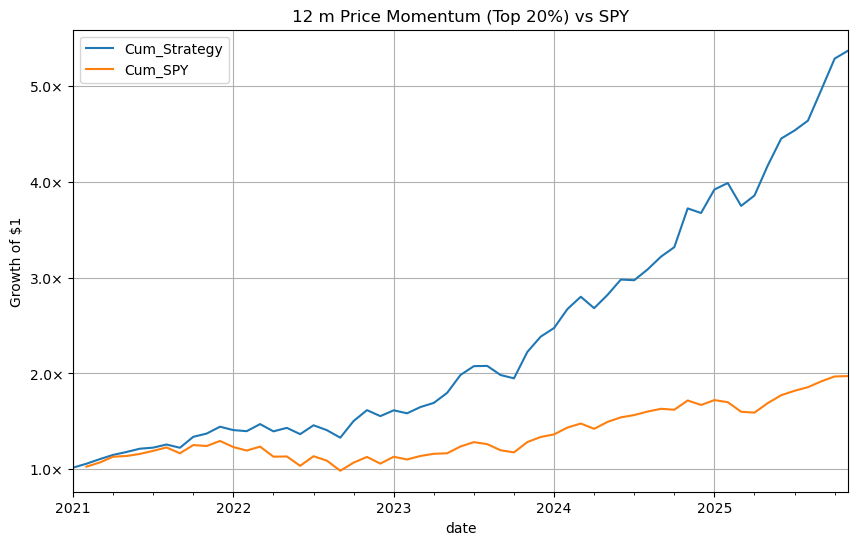

In [105]:
# --- 4) plot ---
fig, ax = plt.subplots(figsize=(10,6))
perf[["Cum_Strategy","Cum_SPY"]].plot(ax=ax)
ax.set_title("12 m Price Momentum (Top 20%) vs SPY")
ax.set_ylabel("Growth of $1")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.1f}×"))
ax.grid(True)
plt.show()

In [106]:
# % of names to go long each month
top_quantile = 0.2  

rebalance_dates = {}

for date, month in data.groupby(level='date', group_keys=False):
    N = int(len(month) * top_quantile)
    if N < 1:
        continue

    # pick the N names with the Highest 12-month return
    top_mom = (
        month
        .nlargest(N, 'return12m')                       # rank by return12m
        .index
        .get_level_values('ticker')
        .tolist()
    )
    rebalance_dates[date] = top_mom

# quick sanity check
for d, tickers in list(rebalance_dates.items())[:3]:
    print(d, tickers[:5], "...", len(tickers), "tickers")


2021-01-31 00:00:00 ['TSLA', 'XYZ', 'NVDA', 'PYPL', 'QCOM'] ... 17 tickers
2021-02-28 00:00:00 ['TSLA', 'XYZ', 'PYPL', 'AMAT', 'NVDA'] ... 17 tickers
2021-03-31 00:00:00 ['TSLA', 'XYZ', 'AMAT', 'GM', 'LRCX'] ... 17 tickers


In [107]:
from curl_cffi import requests
session = requests.Session(impersonate="chrome")

price_hist = {}
for date, tickers in rebalance_dates.items():
    start = (pd.to_datetime(date) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
    end = (pd.to_datetime(date)).strftime('%Y-%m-%d')

    # Include SPY as benchmark
    symbols = tickers + ['SPY']

    df = (
        yf.download(
            tickers = symbols,
            start = start,
            end = end,
            session = session,
            auto_adjust = False,
            progress = False
        )['Adj Close']
    )
    price_hist[date] = df

list(price_hist.items())[:2]

[(Timestamp('2021-01-31 00:00:00'),
  Ticker            AAPL        AMAT        AMD        AMZN       AVGO  \
  Date                                                                   
  2020-01-31   74.608566   54.726387  47.000000  100.435997  26.198282   
  2020-02-03   74.403671   56.359043  48.020000  100.209999  26.204296   
  2020-02-04   76.860008   59.463867  49.450001  102.483498  26.751162   
  2020-02-05   77.486763   60.209412  49.840000  101.993500  27.247381   
  2020-02-06   78.393097   59.633739  49.320000  102.511497  27.445698   
  ...                ...         ...        ...         ...        ...   
  2021-01-25  138.995743  103.411621  94.129997  164.699997  41.725323   
  2021-01-26  139.229172  100.934410  94.709999  166.306503  41.642731   
  2021-01-27  138.159363   94.287079  88.839996  161.628998  39.921803   
  2021-01-28  133.325821   96.745140  87.519997  161.880997  40.553806   
  2021-01-29  128.336685   92.469818  85.639999  160.309998  40.442474   
  

In [108]:
strategy_slices = []

for rebalance_date, tickers in rebalance_dates.items():
    # grab exactly the tickers you chose that month
    df_prices = price_hist[rebalance_date][tickers]  

    # simple equal weights (1/N each)
    w = pd.Series(1/len(tickers), index=tickers)

    # 1) compute daily simple returns
    rets = df_prices.pct_change().dropna(how='all')

    # 2) portfolio daily return = dot(weights, returns)
    rets['Strategy'] = rets.dot(w)

    # 3) tag with the rebalance date and flatten
    strat = (
        rets[['Strategy']]
          .assign(rebalance_date=rebalance_date)
          .set_index('rebalance_date', append=True)
          .swaplevel(0,1)
    )
    strategy_slices.append(strat)

# 4) concatenate all days into one Series and dedupe
portfolio_daily = (
    pd.concat(strategy_slices)['Strategy']
      .sort_index()
      .loc[lambda x: ~x.index.duplicated(keep='first')]
)

# 5) flatten off the rebalance_date index level
strat_u = portfolio_daily.reset_index('rebalance_date', drop=True)

In [109]:
strat_u

Date
2020-02-03    0.027350
2020-02-04    0.038534
2020-02-05   -0.008560
2020-02-06    0.003147
2020-02-07   -0.008163
                ...   
2025-11-21    0.009784
2025-11-24    0.038974
2025-11-25    0.010985
2025-11-26    0.010494
2025-11-28    0.012442
Name: Strategy, Length: 14762, dtype: float64

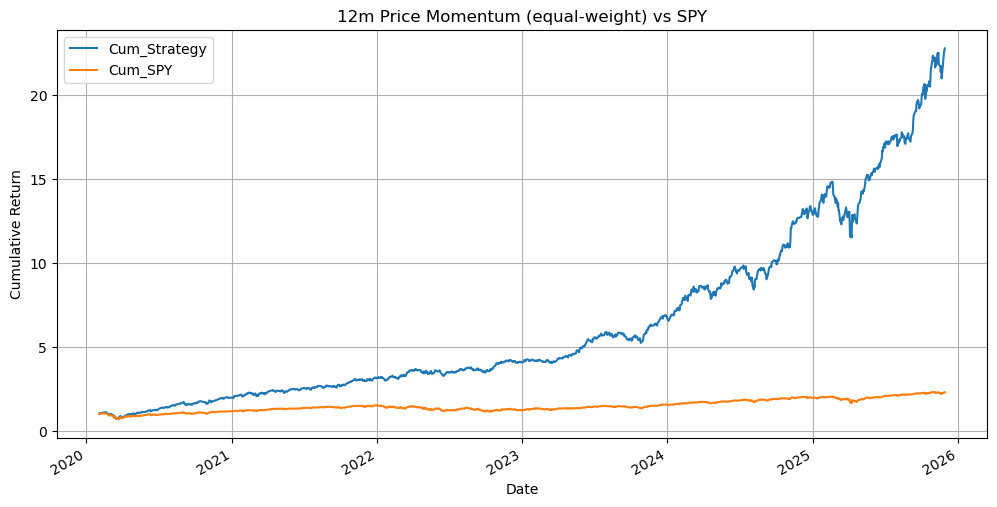

In [110]:
# 1) flatten & dedupe strategy
strat_u = (
    portfolio_daily
    .reset_index('rebalance_date', drop=True)
    .rename('Strategy')
)
strat_u = strat_u[~strat_u.index.duplicated(keep='first')]

# 2) dedupe SPY
# create daily SPY returns
spy_prices_daily = price_hist[list(price_hist.keys())[0]]['SPY']  # take first month as template
for date, df in price_hist.items():
    # merge all daily SPY prices into a single series
    if 'spy_prices_all' not in locals():
        spy_prices_all = df['SPY']
    else:
        spy_prices_all = pd.concat([spy_prices_all, df['SPY']])

spy_prices_all = spy_prices_all[~spy_prices_all.index.duplicated(keep='first')]
spy_u = spy_prices_all.pct_change().rename('SPY').dropna()

spy_u = spy_u[~spy_u.index.duplicated(keep='first')]

# 3) now safe to inner‐join
daily_perf = (
    pd.concat([strat_u, spy_u], axis=1, join='inner')
      .dropna()
)

# 4) cumulative P&L
daily_perf['Cum_Strategy'] = (1 + daily_perf['Strategy']).cumprod()
daily_perf['Cum_SPY']      = (1 + daily_perf['SPY']).cumprod()

# 5) plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12,6))
daily_perf[['Cum_Strategy','Cum_SPY']].plot(ax=ax)
ax.set_title("12m Price Momentum (equal-weight) vs SPY")
ax.set_ylabel("Cumulative Return")
ax.grid(True)
plt.show()

In [111]:
print("Strategy dates:", strat_u.index.min(), strat_u.index.max(), "→", len(strat_u))
print("SPY dates:",     spy_u.index.min(),   spy_u.index.max(),   "→", len(spy_u))

common = strat_u.index.intersection(spy_u.index)
print("Intersection length:", len(common))


Strategy dates: 2020-02-03 00:00:00 2025-11-28 00:00:00 → 1465
SPY dates: 2020-02-03 00:00:00 2025-11-28 00:00:00 → 1465
Intersection length: 1465
